# Evaluación del catálogo definitivo — DEC-MRTAU

**TFM: Asignación distribuida de tareas multi-robot bajo incertidumbre.** Manuel Olías.

Este cuaderno evalúa las cinco políticas de asignación distribuida —`random`, `greedy`, `CBAA`,
`CBBA` y `Dec-MCTS`— sobre el **catálogo v3**, el conjunto de escenarios definitivo del trabajo:
360 escenarios repartidos en **cinco bloques de 72**, cada uno de los cuales aísla un factor del
problema manteniendo el resto fijo.

El análisis se organiza en tres partes:

| Parte | Qué contesta |
|---|---|
| **1 · Análisis conjunto** | ¿Qué dice el catálogo completo? Ranking, dominancia pareada y **hasta qué punto el agregado es un hecho sobre los algoritmos o sobre la composición del catálogo**. |
| **2 · Análisis por bloque** | Un estudio por bloque, con la pregunta que cada uno fue diseñado para responder: equipo (A), ventana (B), carga (C), coaliciones (D) e incertidumbre (E). |
| **3 · Análisis adicional** | Métricas distintas de la objetivo: mortalidad de robots, descomposición intento × éxito, distancia recorrida, coste computacional y ocupación temporal. |

---

### Datos

| | |
|---|---|
| Escenarios | `scenarios/catalogo_v3/` — 360 escenarios, 5 bloques de 72, 10 896 tareas, 12 264 plazas de trabajador |
| Tanda | `logs/eval_catalogo_v3` — 360 × 5 solvers × 3 réplicas = **5 400 ejecuciones** |
| Tabla | `analisis/catalogo_v3.csv`, generada con `scripts/extract_metrics.py` |
| Equipos | de 2 a 10 robots; escenarios de 6 a 80 tareas; batería de capacidad 40 en **todos** ellos |
| Regímenes | ρ = 1 / 0.9 / 0.75 / 0.5 con σ de la duración = 0 / 1 / 3 / 5; un intento **fallido** cuesta 10 de batería en todos ellos |

```bash
python3 scripts/extract_metrics.py logs/eval_catalogo_v3 -o analisis/catalogo_v3.csv
```

**Métrica objetivo**: `final_reward` = fracción de tareas completadas (`reward00` con $k_1 = 1$).

**Unidad de análisis: el escenario**, promediando sus 3 réplicas. Las comparaciones entre solvers
son **pareadas por escenario** y el error estándar se calcula **entre escenarios**, no entre
réplicas: con 4–6 instancias distintas por celda, la varianza entre instancias (±0.15) es un orden
de magnitud mayor que el ruido entre réplicas (±0.016).

> ⚠️ **Aviso que atraviesa todo el cuaderno.** El agregado global del catálogo es un **empate**
> entre `CBBA` y `Dec-MCTS` y su signo depende de qué bloques se incluyan (§1.4). Ninguna
> conclusión debe apoyarse en él: los resultados se leen **por bloque y por régimen**.
>
> ⚠️ Los regímenes `det` y `est` están **equilibrados** entre los cinco bloques (162 escenarios
> cada uno, 36 por bloque salvo E que aporta 18). `lev` y `fue` existen **solo en el bloque E**
> (18 escenarios cada uno). Por eso el gradiente completo de incertidumbre se estudia en §2.5 y
> las figuras con eje de cuatro regímenes se restringen a ese bloque.

## 0 · Preparación

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from pathlib import Path

RUTA = Path('catalogo_v3.csv') if Path('catalogo_v3.csv').exists() else Path('analisis/catalogo_v3.csv')
FIGS = RUTA.parent / 'figuras'; FIGS.mkdir(exist_ok=True)

# ── Paleta (validada para daltonismo: CVD ΔE 9.2, visión normal 16.3, all-pairs) ──
INK, INK2, MUTED    = '#0b0b0b', '#52514e', '#898781'
GRID, AXIS, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
NEG, POS, MID       = '#e34948', '#2a78d6', '#f0efec'      # divergente: rojo ↔ azul
DIV = LinearSegmentedColormap.from_list('div', [NEG, MID, POS])

COLOR  = {'cbba': '#2a78d6', 'dec-mcts-v4-g9999': '#eb6834',
          'cbaa': '#1baf7a', 'greedy': '#4a3aa7', 'random': MUTED}
NOMBRE = {'cbba': 'CBBA', 'dec-mcts-v4-g9999': 'Dec-MCTS', 'cbaa': 'CBAA',
          'greedy': 'Greedy', 'random': 'Random'}
SOLVERS = ['random', 'greedy', 'cbaa', 'cbba', 'dec-mcts-v4-g9999']
DEC, REF = 'dec-mcts-v4-g9999', 'cbba'

REGS    = ['det', 'lev', 'est', 'fue']
REGIMEN = {'det': 'determinista\nρ=1.0  σ=0', 'lev': 'leve\nρ=0.9  σ=1',
           'est': 'media\nρ=0.75  σ=3', 'fue': 'fuerte\nρ=0.5  σ=5'}
BLOQUE  = {'A': 'A · equipo', 'B': 'B · ventana', 'C': 'C · carga',
           'D': 'D · coaliciones', 'E': 'E · incertidumbre'}
BLOQUE2 = {b: v.replace(' · ', '\n') for b, v in BLOQUE.items()}   # etiqueta de dos líneas
VENTANA = {'E': 'E · estrecha\n(espera+plazo)', 'P': 'P · solo plazo\n(sin espera)',
           'C': 'C · plazo\nescalonado', 'A': 'A · ancha'}

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'legend.frameon': False, 'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})

def guardar(fig, nombre):
    '''Guarda la figura en PNG y PDF para poder incrustarla en la memoria.'''
    fig.savefig(FIGS / f'{nombre}.png'); fig.savefig(FIGS / f'{nombre}.pdf')

print(f'Estilo listo · figuras → {FIGS}')

Estilo listo · figuras → figuras


In [2]:
df = pd.read_csv(RUTA, low_memory=False)
for c in ('robots', 'tareas', 'instancia', 'replica'):
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Carga por robot  L = Σ_j q_j / R.  La mezcla `qm` (1-2-3) está calibrada a q̄ = 2.
QBAR = {'q1': 1, 'q2': 2, 'qm': 2}
df['carga'] = (df.tareas * df.coalicion.map(QBAR) / df.robots).round().astype(int)

# ── Unidad de análisis: el ESCENARIO (media de sus 3 réplicas) ──
FACTORES = ['bloque', 'robots', 'tareas', 'ventana', 'regimen', 'coalicion', 'instancia', 'carga']
esc = (df.groupby(['escenario'] + FACTORES + ['solver'], as_index=False)
         .agg(recompensa  = ('final_reward', 'mean'),
              completadas = ('completed_tasks', 'mean'),
              intento     = ('tasa_intento', 'mean'),
              exito       = ('tasa_exito', 'mean'),
              intentadas  = ('tareas_intentadas', 'mean'),
              muertos     = ('failed_agents', 'mean'),
              distancia   = ('sum_robot_travel_distance', 'mean'),
              dist_robot  = ('average_robot_travel_distance', 'mean'),
              makespan    = ('max_robot_makespan', 'mean'),
              retiro      = ('t_retiro_medio', 'mean'),
              cpu         = ('computing_time', 'mean')))

META = esc.drop_duplicates('escenario').set_index('escenario')[FACTORES]

def ancho(metrica):
    '''Tabla escenario × solver de una métrica, con los factores del escenario adjuntos.'''
    return esc.pivot(index='escenario', columns='solver', values=metrica).join(META)

W = ancho('recompensa'); W['delta'] = W[DEC] - W[REF]     # Δ pareada Dec-MCTS − CBBA

def stats_delta(x):
    '''Media, error estándar entre escenarios, t y recuento gana/empata/pierde.'''
    x = pd.Series(x).dropna()
    g, p = int((x > 1e-9).sum()), int((x < -1e-9).sum())
    return pd.Series({'Δ': x.mean(), 'EE': x.sem(), 't': x.mean() / x.sem(),
                      'n': len(x), 'G': g, 'E': len(x) - g - p, 'P': p})

def fila(d):
    '''Medias de los cinco solvers + Δ pareada + mejor solver, sobre un corte del catálogo.'''
    m = d[SOLVERS].mean()
    return pd.concat([m.rename(NOMBRE), stats_delta(d[DEC] - d[REF]),
                      pd.Series({'mejor': NOMBRE[m.idxmax()]})])

def panel(w, por=None, metrica='recompensa'):
    '''Tabla-resumen de un corte (o de sus grupos) para la métrica indicada.'''
    if metrica != 'recompensa':
        w = ancho(metrica).loc[w.index]
    if por is None:
        return fila(w).to_frame('catálogo completo').T
    return w.groupby(por, observed=True).apply(fila, include_groups=False)

uno = df.drop_duplicates('escenario')
print(f'{len(df):,} ejecuciones · {esc.escenario.nunique()} escenarios · '
      f'{int(df.replica.max())} réplicas · {len(SOLVERS)} solvers')
print(f'{int(uno.tareas.sum()):,} tareas · '
      f'{int((uno.tareas * uno.coalicion.map(QBAR)).sum()):,} plazas de trabajador')
print('escenarios por bloque y régimen:')
display(pd.crosstab(META.bloque, META.regimen)[REGS])

5,400 ejecuciones · 360 escenarios · 3 réplicas · 5 solvers
10,896 tareas · 12,264 plazas de trabajador
escenarios por bloque y régimen:


regimen,det,lev,est,fue
bloque,,,,
A,36,0,36,0
B,36,0,36,0
C,36,0,36,0
D,36,0,36,0
E,18,18,18,18


---

# Parte 1 · Análisis conjunto

Los 360 escenarios tratados como un solo conjunto. El objetivo de esta parte no es solo ordenar
los cinco algoritmos, sino **medir cuánta confianza merece esa ordenación**: cuál es el margen,
cuántos escenarios gana realmente cada uno y qué le ocurre al resultado si se cambia la
composición del catálogo.

## 1.1 · Panorama: ranking global y por bloque

In [3]:
tabla = (esc.groupby('solver').recompensa.agg(['mean', 'sem', 'std'])
            .reindex(SOLVERS).rename(index=NOMBRE)
            .rename(columns={'mean': 'recompensa media', 'sem': 'EE', 'std': 'σ entre escenarios'}))
por_bloque = (W.groupby('bloque')[SOLVERS].mean().T.rename(index=NOMBRE)
                .rename(columns=BLOQUE))
display(tabla.join(por_bloque).round(3))

,recompensa media,EE,σ entre escenarios,A · equipo,B · ventana,C · carga,D · coaliciones,E · incertidumbre
solver,,,,,,,,
Random,0.271,0.005,0.099,0.269,0.317,0.359,0.169,0.241
Greedy,0.354,0.006,0.113,0.327,0.452,0.404,0.287,0.302
CBAA,0.437,0.007,0.124,0.406,0.480,0.460,0.431,0.407
CBBA,0.494,0.007,0.133,0.511,0.525,0.560,0.407,0.466
Dec-MCTS,0.502,0.008,0.148,0.497,0.546,0.621,0.401,0.446


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


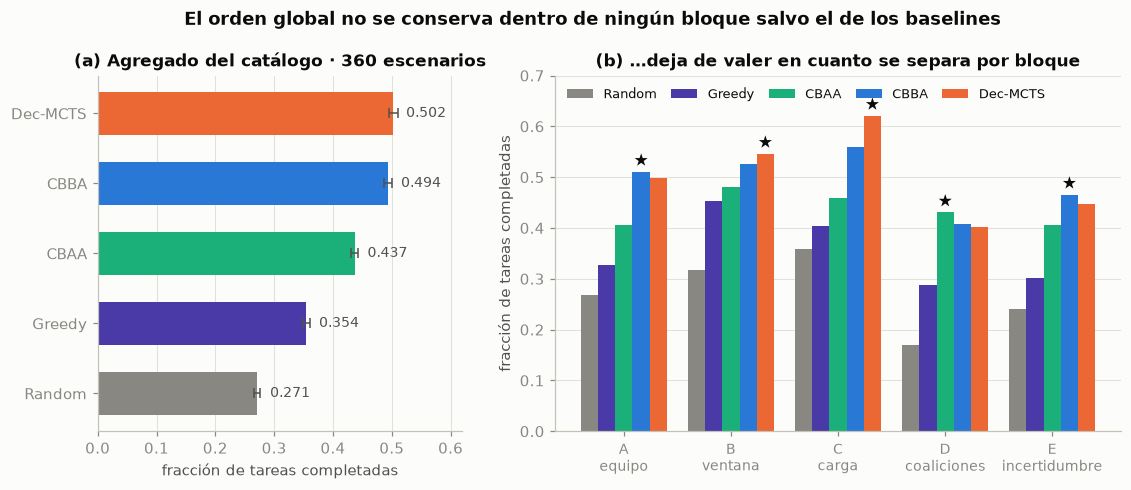

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2),
                               gridspec_kw={'width_ratios': [1, 1.55]})

# (a) ranking global
orden = esc.groupby('solver').recompensa.mean().reindex(SOLVERS)
err   = esc.groupby('solver').recompensa.sem().reindex(SOLVERS)
ax1.barh(range(5), orden.values, height=0.62, color=[COLOR[s] for s in orden.index],
         xerr=err.values, error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax1.set_yticks(range(5), [NOMBRE[s] for s in orden.index])
for i, v in enumerate(orden.values):
    ax1.text(v + 0.022, i, f'{v:.3f}', va='center', fontsize=9, color=INK2)
ax1.set_xlim(0, 0.62); ax1.set_xlabel('fracción de tareas completadas')
ax1.set_title('(a) Agregado del catálogo · 360 escenarios')
ax1.grid(axis='y', visible=False)

# (b) el mismo ranking, bloque a bloque
bl = W.groupby('bloque')[SOLVERS].mean()
x = np.arange(len(bl)); w = 0.16
for k, s in enumerate(SOLVERS):
    ax2.bar(x + (k - 2) * w, bl[s].values, w, color=COLOR[s], label=NOMBRE[s])
for i, b in enumerate(bl.index):                      # marca el ganador de cada bloque
    j = SOLVERS.index(bl.loc[b].idxmax())
    ax2.text(i + (j - 2) * w, bl.loc[b].max() + 0.012, '★', ha='center',
             fontsize=11, color=INK)
ax2.set_xticks(x, [BLOQUE2[b] for b in bl.index], fontsize=9)
ax2.set_ylim(0, 0.70); ax2.set_ylabel('fracción de tareas completadas')
ax2.set_title('(b) …deja de valer en cuanto se separa por bloque')
ax2.grid(axis='x', visible=False)
ax2.legend(loc='upper left', ncol=5, fontsize=8.5, columnspacing=1.1)

fig.suptitle('El orden global no se conserva dentro de ningún bloque salvo el de los baselines',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_panorama'); plt.show()

**Lectura.** Sobre el agregado los cinco algoritmos quedan ordenados
`Random < Greedy < CBAA < CBBA ≈ Dec-MCTS`, con **0.271 / 0.354 / 0.437 / 0.494 / 0.502**. Los
dos primeros escalones son grandes e inequívocos: coordinar mediante subastas vale ~0.08 de
recompensa sobre la heurística voraz, y pujar por paquetes (CBBA) vale otros ~0.06 sobre pujar por
tarea suelta (CBAA). Esa parte del ranking **no cambia en ningún corte del catálogo**.

El último escalón, en cambio, **es ruido de composición**: 0.008 de diferencia entre CBBA y
Dec-MCTS, con una desviación típica entre escenarios de ~0.14. El panel (b) lo hace evidente —el
ganador cambia de bloque en bloque: `CBBA` en A y E, `Dec-MCTS` en B y C, y `CBAA` —que es el
tercero global— **gana el bloque D**. La parte 2 es, por tanto, el análisis que de verdad informa.

## 1.2 · El agregado es un empate, no una victoria

In [5]:
print('Δ pareada  Dec-MCTS − CBBA  (unidad: el escenario)')
display(pd.concat([stats_delta(W.delta).to_frame('catálogo completo').T,
                   W.groupby('regimen').delta.apply(stats_delta).unstack().reindex(REGS)]).round(4))
q = W.delta.quantile([.05, .25, .50, .75, .95]).round(3)
print(f'\nDistribución de la Δ:  mediana {q[.50]:+.3f} · rango intercuartílico '
      f'[{q[.25]:+.3f}, {q[.75]:+.3f}] · deciles extremos [{q[.05]:+.3f}, {q[.95]:+.3f}]')
print(f'En {int((W.delta.abs() < 0.02).sum())} de {len(W)} escenarios la diferencia es menor de 0.02 '
      f'(≈ una tarea de cada cincuenta).')

Δ pareada  Dec-MCTS − CBBA  (unidad: el escenario)


,Δ,EE,t,n,G,E,P
catálogo completo,0.0086,0.0040,2.1391,360.0,158.0,42.0,160.0
det,0.0201,0.0055,3.6248,162.0,76.0,30.0,56.0
lev,-0.0099,0.0153,-0.6452,18.0,4.0,3.0,11.0
est,0.0057,0.0064,0.8970,162.0,74.0,9.0,79.0
fue,-0.0497,0.0167,-2.9681,18.0,4.0,0.0,14.0



Distribución de la Δ:  mediana +0.000 · rango intercuartílico [-0.040, +0.044] · deciles extremos [-0.100, +0.149]
En 108 de 360 escenarios la diferencia es menor de 0.02 (≈ una tarea de cada cincuenta).


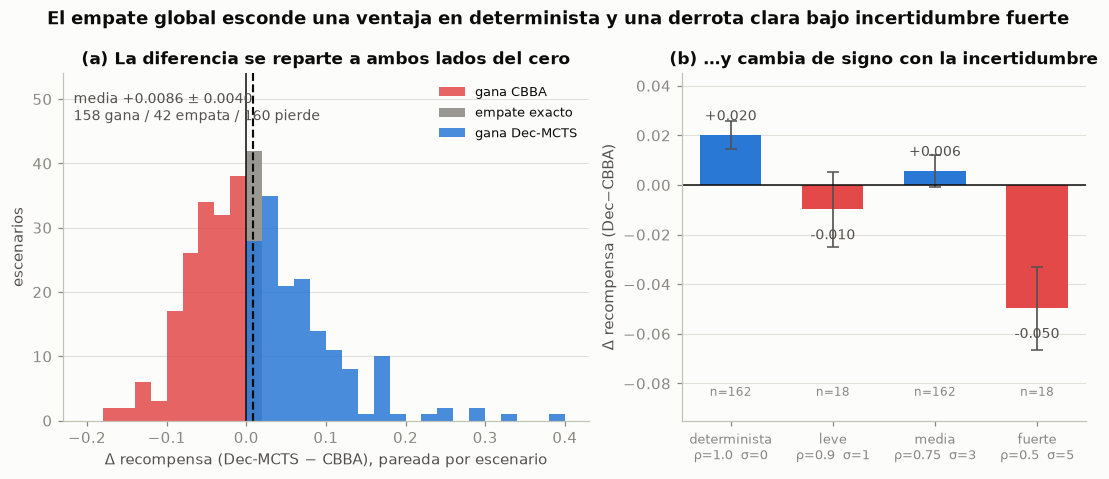

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1),
                               gridspec_kw={'width_ratios': [1.3, 1]})

# (a) distribución de la Δ pareada
b = np.arange(-0.20, 0.42, 0.02)
ax1.hist(W.delta[W.delta < -1e-9], bins=b, color=NEG, alpha=.85, label='gana CBBA')
ax1.hist(W.delta[W.delta.abs() <= 1e-9], bins=b, color=MUTED, alpha=.85, label='empate exacto')
ax1.hist(W.delta[W.delta > 1e-9], bins=b, color=POS, alpha=.85, label='gana Dec-MCTS')
ax1.axvline(0, color=INK, lw=1)
ax1.axvline(W.delta.mean(), color=INK, lw=1.4, ls='--')
g, e, p = int((W.delta > 1e-9).sum()), int((W.delta.abs() <= 1e-9).sum()), int((W.delta < -1e-9).sum())
ax1.text(0.02, 0.95, f'media {W.delta.mean():+.4f} ± {W.delta.sem():.4f}\n'
         f'{g} gana / {e} empata / {p} pierde', transform=ax1.transAxes,
         va='top', fontsize=9, color=INK2)
ax1.set_xlabel('Δ recompensa (Dec-MCTS − CBBA), pareada por escenario')
ax1.set_ylabel('escenarios'); ax1.set_ylim(0, 54)
ax1.set_title('(a) La diferencia se reparte a ambos lados del cero')
ax1.legend(fontsize=8.5, loc='upper right'); ax1.grid(axis='x', visible=False)

# (b) Δ por régimen de incertidumbre
d = W.groupby('regimen').delta.agg(['mean', 'sem', 'count']).reindex(REGS)
col = [POS if v > 0 else NEG for v in d['mean']]
ax2.bar(range(4), d['mean'], 0.6, color=col, yerr=d['sem'],
        error_kw=dict(ecolor=INK2, elinewidth=1.1, capsize=4))
ax2.axhline(0, color=INK, lw=1)
for i, (v, n) in enumerate(zip(d['mean'], d['count'])):
    ax2.text(i, v + (0.006 if v > 0 else -0.012), f'{v:+.3f}', ha='center', fontsize=9, color=INK2)
    ax2.text(i, -0.085, f'n={n}', ha='center', fontsize=8, color=MUTED)
ax2.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax2.set_ylim(-0.095, 0.045); ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) …y cambia de signo con la incertidumbre')
ax2.grid(axis='x', visible=False)

fig.suptitle('El empate global esconde una ventaja en determinista y una derrota clara bajo incertidumbre fuerte',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_agregado'); plt.show()

**Lectura.** La Δ pareada global es **+0.0086 ± 0.0040** (t = 2.1) pero el recuento de escenarios
es **158 gana / 42 empata / 160 pierde**: una moneda al aire. La mediana de la Δ es exactamente
**0.000** y en 108 de los 360 escenarios la diferencia es inferior a 0.02. Un intervalo de
confianza que excluye al cero por poco, sobre una distribución centrada en cero y con colas
simétricas de ±0.1, **no es una victoria**; es una diferencia de composición.

Por régimen el resultado sí es informativo y no es el mismo en los cuatro:

- **determinista** (ρ=1, σ=0): **+0.0201 ± 0.0055** — Dec-MCTS gana, y aquí sí con margen.
- **leve** (ρ=0.9, σ=1): −0.0099 ± 0.0153 — indistinguible de cero.
- **media** (ρ=0.75, σ=3): +0.0057 ± 0.0064 — empate.
- **fuerte** (ρ=0.5, σ=5): **−0.0497 ± 0.0167** — Dec-MCTS pierde con claridad.

Es decir: **la anticipación paga mientras los planes son predecibles y deja de pagar en cuanto
dejan de serlo**. `lev` y `fue` proceden solo del bloque E (18 escenarios cada uno), de ahí sus
errores estándar grandes; el gradiente completo se estudia en §2.5.

## 1.3 · Dominancia pareada: quién gana a quién, escenario a escenario

In [7]:
M   = esc.pivot(index='escenario', columns='solver', values='recompensa')
vic = pd.DataFrame({a: {b: int((M[a] > M[b] + 1e-9).sum()) for b in SOLVERS} for a in SOLVERS}).T
vic = vic.reindex(index=SOLVERS[::-1], columns=SOLVERS[::-1]).rename(index=NOMBRE, columns=NOMBRE)
print('Victorias pareadas: la FILA gana a la COLUMNA, sobre 360 escenarios')
display(vic)

ganador = M[SOLVERS].idxmax(axis=1).map(NOMBRE)
arrep   = (M[SOLVERS].max(axis=1).values[:, None] - M[SOLVERS].values).mean(0)
resumen_glob = pd.DataFrame({'ganador absoluto (escenarios)': ganador.value_counts().reindex(
                                 [NOMBRE[s] for s in SOLVERS]).fillna(0).astype(int),
                             'arrepentimiento medio': np.round(arrep, 4)},
                            index=[NOMBRE[s] for s in SOLVERS])
display(resumen_glob)
print('Arrepentimiento = distancia media al mejor solver DE CADA escenario. Mide el coste de\n'
      'elegir un único algoritmo a ciegas para todo el catálogo.')

Victorias pareadas: la FILA gana a la COLUMNA, sobre 360 escenarios


,Dec-MCTS,CBBA,CBAA,Greedy,Random
Dec-MCTS,0,158,219,333,358
CBBA,160,0,209,309,349
CBAA,98,103,0,264,326
Greedy,13,24,75,0,305
Random,0,6,28,40,0


,ganador absoluto (escenarios),arrepentimiento medio
Random,0,0.2655
Greedy,14,0.1822
CBAA,107,0.0999
CBBA,131,0.0429
Dec-MCTS,108,0.0342


Arrepentimiento = distancia media al mejor solver DE CADA escenario. Mide el coste de
elegir un único algoritmo a ciegas para todo el catálogo.


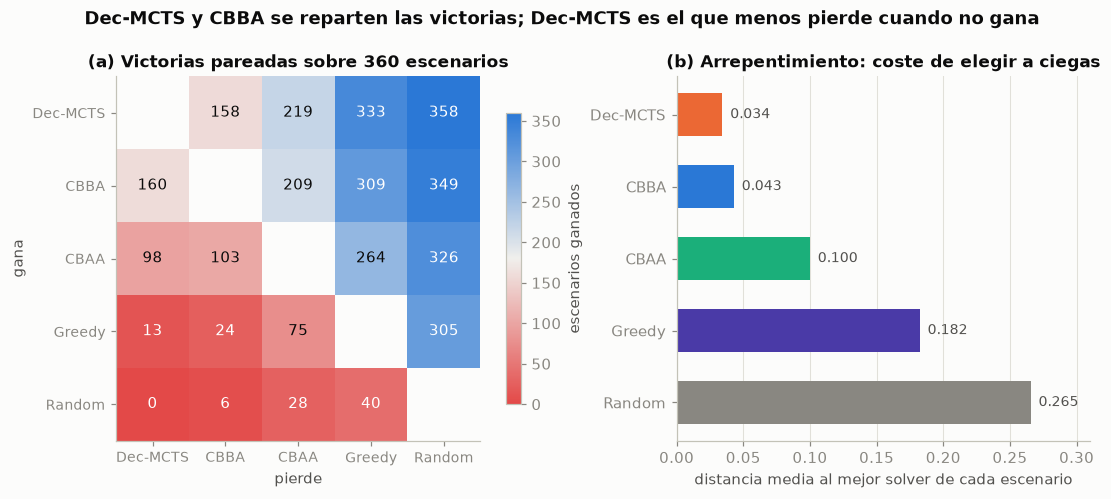

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3),
                               gridspec_kw={'width_ratios': [1.25, 1]})

# (a) matriz de dominancia
m = vic.values.astype(float); np.fill_diagonal(m, np.nan)
im = ax1.imshow(m, cmap=DIV, norm=TwoSlopeNorm(vmin=0, vcenter=180, vmax=360))
for i in range(5):
    for j in range(5):
        if i != j:
            ax1.text(j, i, int(m[i, j]), ha='center', va='center', fontsize=9.5,
                     color='white' if abs(m[i, j] - 180) > 110 else INK)
ax1.set_xticks(range(5), vic.columns, fontsize=9); ax1.set_yticks(range(5), vic.index, fontsize=9)
ax1.set_xlabel('pierde'); ax1.set_ylabel('gana')
ax1.set_title('(a) Victorias pareadas sobre 360 escenarios')
ax1.grid(False)
fig.colorbar(im, ax=ax1, shrink=.8, label='escenarios ganados')

# (b) arrepentimiento medio
o = np.argsort(-arrep)
ax2.barh(range(5), arrep[o], height=0.6, color=[COLOR[SOLVERS[k]] for k in o])
ax2.set_yticks(range(5), [NOMBRE[SOLVERS[k]] for k in o])
for i, k in enumerate(o):
    ax2.text(arrep[k] + 0.006, i, f'{arrep[k]:.3f}', va='center', fontsize=9, color=INK2)
ax2.set_xlim(0, 0.31); ax2.set_xlabel('distancia media al mejor solver de cada escenario')
ax2.set_title('(b) Arrepentimiento: coste de elegir a ciegas')
ax2.grid(axis='y', visible=False)

fig.suptitle('Dec-MCTS y CBBA se reparten las victorias; Dec-MCTS es el que menos pierde cuando no gana',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_dominancia'); plt.show()

**Lectura.** La matriz de dominancia confirma que los tres primeros escalones son **estrictos**:
Dec-MCTS gana a `Random` en 358 de 360 escenarios y a `Greedy` en 333; CBBA gana a `CBAA` en 209
de 360. El último escalón es **simétrico**: 158 a 160 entre Dec-MCTS y CBBA.

Dos observaciones que solo aparecen en el recuento absoluto:

1. **`CBAA` gana 107 escenarios por completo**, casi tantos como Dec-MCTS (108), pese a quedar
   0.065 por debajo en el agregado. Su perfil no es «peor en todo», sino **muy bueno en un
   subconjunto concreto** —el bloque de coaliciones, §2.4— y mediocre en el resto.
2. **El arrepentimiento medio de Dec-MCTS (0.034) es el menor de los cinco**, por debajo del de
   CBBA (0.043). Ganar menos escenarios y perder menos recompensa a la vez es coherente con lo
   visto en §1.2: cuando Dec-MCTS gana, gana por poco; cuando pierde, también. Es el algoritmo
   más **regular** del catálogo, no el más fuerte.

## 1.4 · Cuánto de este resultado es del algoritmo y cuánto del catálogo

In [9]:
por_bl = panel(W, 'bloque').rename(index=BLOQUE)
print('Δ pareada Dec-MCTS − CBBA por bloque')
display(por_bl.round(3))

# Dejar fuera un bloque cada vez: ¿cuánto se mueve el agregado global?
lobo = pd.DataFrame({BLOQUE[b]: {'Δ global sin ese bloque': W[W.bloque != b].delta.mean(),
                                 'mejor solver': NOMBRE[W[W.bloque != b][SOLVERS].mean().idxmax()]}
                     for b in 'ABCDE'}).T
lobo.insert(0, 'Δ global (completo)', W.delta.mean())
display(lobo.round(4))

Δ pareada Dec-MCTS − CBBA por bloque


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,mejor
bloque,,,,,,,,,,,,,
A · equipo,0.269,0.327,0.406,0.511,0.497,-0.013,0.006,-2.088,72.0,21.0,12.0,39.0,CBBA
B · ventana,0.317,0.452,0.480,0.525,0.546,0.021,0.007,3.086,72.0,42.0,9.0,21.0,Dec-MCTS
C · carga,0.359,0.404,0.460,0.560,0.621,0.061,0.013,4.789,72.0,47.0,2.0,23.0,Dec-MCTS
D · coaliciones,0.169,0.287,0.431,0.407,0.401,-0.006,0.007,-0.809,72.0,27.0,11.0,34.0,CBAA
E · incertidumbre,0.241,0.302,0.407,0.466,0.446,-0.019,0.007,-2.718,72.0,21.0,8.0,43.0,CBBA


,Δ global (completo),Δ global sin ese bloque,mejor solver
A · equipo,0.0086,0.014087,Dec-MCTS
B · ventana,0.0086,0.005529,Dec-MCTS
C · carga,0.0086,-0.004333,CBBA
D · coaliciones,0.0086,0.0123,Dec-MCTS
E · incertidumbre,0.0086,0.015599,Dec-MCTS


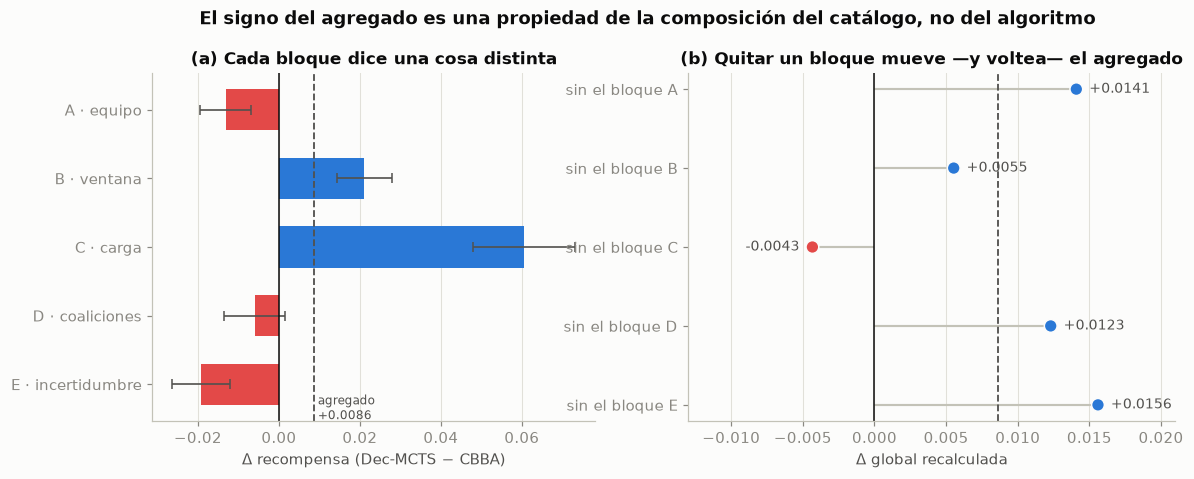

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1), gridspec_kw={'width_ratios': [1, 1.1]})

# (a) Δ por bloque
d = W.groupby('bloque').delta.agg(['mean', 'sem'])
y = np.arange(len(d))
ax1.barh(y, d['mean'], 0.6, color=[POS if v > 0 else NEG for v in d['mean']],
         xerr=d['sem'], error_kw=dict(ecolor=INK2, elinewidth=1.1, capsize=3))
ax1.axvline(0, color=INK, lw=1)
ax1.axvline(W.delta.mean(), color=INK2, lw=1.2, ls='--')
ax1.text(W.delta.mean(), 4.35, f' agregado\n {W.delta.mean():+.4f}', fontsize=8, color=INK2, va='center')
ax1.set_yticks(y, [BLOQUE[b] for b in d.index]); ax1.invert_yaxis()
ax1.set_xlabel('Δ recompensa (Dec-MCTS − CBBA)')
ax1.set_title('(a) Cada bloque dice una cosa distinta'); ax1.grid(axis='y', visible=False)

# (b) leave-one-block-out del agregado
vals = [W[W.bloque != b].delta.mean() for b in 'ABCDE']
ax2.hlines(range(5), 0, vals, color=AXIS, lw=1.4)
ax2.scatter(vals, range(5), s=70, zorder=3,
            color=[POS if v > 0 else NEG for v in vals], edgecolor=SURFACE, linewidth=1)
ax2.axvline(0, color=INK, lw=1)
ax2.axvline(W.delta.mean(), color=INK2, lw=1.2, ls='--')
for i, v in enumerate(vals):
    ax2.text(v + (0.0009 if v > 0 else -0.0009), i, f'{v:+.4f}',
             va='center', ha='left' if v > 0 else 'right', fontsize=9, color=INK2)
ax2.set_yticks(range(5), [f'sin el bloque {b}' for b in 'ABCDE']); ax2.invert_yaxis()
ax2.set_xlim(-0.013, 0.021); ax2.set_xlabel('Δ global recalculada')
ax2.set_title('(b) Quitar un bloque mueve —y voltea— el agregado')
ax2.grid(axis='y', visible=False)

fig.suptitle('El signo del agregado es una propiedad de la composición del catálogo, no del algoritmo',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p1_composicion'); plt.show()

**Lectura — y la lección metodológica del trabajo.** El agregado global (+0.0086) es una media
ponderada de cinco resultados que **no apuntan en la misma dirección**: C **+0.061**, B **+0.021**,
D −0.006, A −0.013, E −0.019. Bastan dos hechos para desactivarlo como argumento:

- **Quitar el bloque C invierte el signo** del agregado (+0.0086 → −0.0043), y con él el orden de
  los dos primeros solvers. Quitar A o E lo casi duplica (+0.014 / +0.016).
- Ningún bloque está sobrerrepresentado: los cinco aportan exactamente 72 escenarios. La
  inversión no viene de un desequilibrio de tamaño, sino de **qué factores decidió el catálogo
  barrer**, que es una decisión del diseñador.

Esto obliga a una declaración de honestidad que acompaña a todos los resultados de este trabajo:
**el agregado de un catálogo de MRTA no es un hecho sobre el algoritmo, es una propiedad de la
composición del catálogo.** Auditada a posteriori, la composición del v3 tiene 2 de los 3 niveles
de B (ventanas `P` y `C`) y 2 de los 3 de C (cargas L=3 y L=4) en terreno favorable a Dec-MCTS,
mientras que A, D y E le son adversos. No está escorada a propósito —los niveles se fijaron antes
de medir—, pero **el resultado global depende de ella y hay que decirlo**.

---

# Parte 2 · Análisis por bloque

Cada bloque aísla **un solo factor** sobre la configuración de referencia (L = 6, ventana
estrecha, $q_j = 1$, horizonte T = 40), que es justamente la del **bloque A**. Los bloques B, C y
D varían ese factor sobre $R \in \{2,5,10\}$ (D usa $\{3,6,10\}$) y se comparan **contra las
celdas de A a esos mismos $R$**, con la misma semilla: misma geometría, mismos plazos y mismos
sorteos. El pareado es por tanto exacto y el contraste mide el **efecto del factor**, no la
diferencia entre dos muestras distintas.

| Bloque | Factor barrido | Niveles | Control |
|---|---|---|---|
| **A** | tamaño del equipo | $R = 2 \dots 10$ | — (es el control) |
| **B** | forma de la ventana | `P` solo plazo · `C` plazo escalonado · `A` ancha | `E` estrecha (A) |
| **C** | carga por robot | $L = 3, 4, 8$ | $L = 6$ (A) |
| **D** | coaliciones | `q2` dos trabajadores · `qm` mezcla 1-2-3 | `q1` (A) |
| **E** | incertidumbre | $\rho = 1.0, 0.9, 0.75, 0.5$ | `det` es un extremo del propio gradiente |

In [11]:
print('Resumen por bloque — medias de los cinco solvers y Δ pareada Dec-MCTS − CBBA')
display(panel(W, 'bloque').rename(index=BLOQUE).round(3))
print('\nY el mismo desglose separando régimen determinista de estocástico:')
display(panel(W, ['bloque', 'regimen']).rename(index=BLOQUE).round(3))

Resumen por bloque — medias de los cinco solvers y Δ pareada Dec-MCTS − CBBA


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,mejor
bloque,,,,,,,,,,,,,
A · equipo,0.269,0.327,0.406,0.511,0.497,-0.013,0.006,-2.088,72.0,21.0,12.0,39.0,CBBA
B · ventana,0.317,0.452,0.480,0.525,0.546,0.021,0.007,3.086,72.0,42.0,9.0,21.0,Dec-MCTS
C · carga,0.359,0.404,0.460,0.560,0.621,0.061,0.013,4.789,72.0,47.0,2.0,23.0,Dec-MCTS
D · coaliciones,0.169,0.287,0.431,0.407,0.401,-0.006,0.007,-0.809,72.0,27.0,11.0,34.0,CBAA
E · incertidumbre,0.241,0.302,0.407,0.466,0.446,-0.019,0.007,-2.718,72.0,21.0,8.0,43.0,CBBA



Y el mismo desglose separando régimen determinista de estocástico:


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ  \
bloque            regimen                                                  
A · equipo        det       0.296   0.368  0.488  0.576     0.577  0.000   
                  est       0.241   0.285  0.325  0.445     0.418 -0.027   
B · ventana       det       0.347   0.499  0.514  0.572     0.600  0.027   
                  est       0.287   0.406  0.447  0.477     0.492  0.015   
C · carga         det       0.398   0.452  0.545  0.639     0.713  0.074   
                  est       0.320   0.356  0.374  0.481     0.529  0.047   
D · coaliciones   det       0.196   0.309  0.495  0.472     0.457 -0.015   
                  est       0.142   0.265  0.366  0.343     0.345  0.003   
E · incertidumbre det       0.302   0.365  0.524  0.563     0.570  0.007   
                  est       0.241   0.295  0.369  0.452     0.428 -0.024   
                  fue       0.162   0.207  0.263  0.328     0.278 -0.050   
                  lev       0.261   0.340  0.471  0.520     0.510 -0.010   

                              EE      t     n     G    E     P     mejor  
bloque            regimen                                                 
A · equipo        det      0.006  0.074  36.0  12.0  9.0  15.0  Dec-MCTS  
                  est      0.011 -2.474  36.0   9.0  3.0  24.0      CBBA  
B · ventana       det      0.010  2.667  36.0  20.0  9.0   7.0  Dec-MCTS  
                  est      0.009  1.633  36.0  22.0  0.0  14.0  Dec-MCTS  
C · carga         det      0.015  4.952  36.0  26.0  1.0   9.0  Dec-MCTS  
                  est      0.020  2.317  36.0  21.0  1.0  14.0  Dec-MCTS  
D · coaliciones   det      0.011 -1.280  36.0  12.0  6.0  18.0      CBAA  
                  est      0.009  0.271  36.0  15.0  5.0  16.0      CBAA  
E · incertidumbre det      0.007  0.940  18.0   6.0  5.0   7.0  Dec-MCTS  
                  est      0.013 -1.864  18.0   7.0  0.0  11.0      CBBA  
                  fue      0.017 -2.968  18.0   4.0  0.0  14.0      CBBA  
                  lev      0.015 -0.645  18.0   4.0  3.0  11.0      CBBA

## 2.1 · Bloque A — escalado con el tamaño del equipo

El bloque de control: 9 tamaños de equipo ($R = 2 \dots 10$) a **iso-dificultad**, con carga por
robot constante $L = 6$ y horizonte fijo $T = 40$, de modo que «más robots» significa
**exactamente** más robots y no «menos trabajo por robot». La pregunta del bloque es la que mejor
separa a una política de coordinación de una heurística: **¿convierte cada robot adicional en
rendimiento?**

In [12]:
A = W[W.bloque == 'A']

def pendiente(x, y):
    '''Pendiente OLS y su estadístico t.'''
    x, y = np.asarray(x, float), np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    r = y - (a + b * x)
    se = np.sqrt((r ** 2).sum() / (len(x) - 2) / ((x - x.mean()) ** 2).sum())
    return b, b / se

print('Recompensa media frente al nº de robots (iso-dificultad L=6)')
display(A.groupby(['regimen', 'robots'])[SOLVERS + ['delta']].mean()
         .rename(columns=NOMBRE).round(3))

print('\nPendiente por robot adicional (OLS sobre los 36 escenarios de cada régimen)')
pend = pd.DataFrame({NOMBRE[s]: {r: '{:+.4f} (t={:.1f})'.format(*pendiente(A[A.regimen == r].robots,
                                                                          A[A.regimen == r][s]))
                                 for r in ('det', 'est')} for s in SOLVERS})
pend['Δ  (Dec − CBBA)'] = {r: '{:+.4f} (t={:.1f})'.format(*pendiente(A[A.regimen == r].robots,
                                                                    A[A.regimen == r].delta))
                           for r in ('det', 'est')}
display(pend)

Recompensa media frente al nº de robots (iso-dificultad L=6)


Random  Greedy   CBAA   CBBA  Dec-MCTS  delta
regimen robots                                               
det     2        0.326   0.354  0.542  0.500     0.521  0.021
        3        0.273   0.361  0.472  0.514     0.528  0.014
        4        0.292   0.354  0.490  0.552     0.556  0.003
        5        0.317   0.375  0.508  0.569     0.581  0.011
        6        0.280   0.354  0.391  0.583     0.574 -0.009
        7        0.298   0.359  0.482  0.601     0.607  0.006
        8        0.286   0.396  0.557  0.625     0.611 -0.014
        9        0.284   0.412  0.440  0.611     0.593 -0.019
        10       0.310   0.350  0.508  0.629     0.619 -0.010
est     2        0.257   0.299  0.389  0.340     0.410  0.069
        3        0.245   0.273  0.287  0.370     0.398  0.028
        4        0.229   0.250  0.288  0.441     0.399 -0.042
        5        0.250   0.294  0.378  0.450     0.428 -0.022
        6        0.231   0.280  0.271  0.426     0.398 -0.028
        7        0.228   0.276  0.349  0.486     0.450 -0.036
        8        0.238   0.292  0.344  0.497     0.432 -0.064
        9        0.250   0.319  0.278  0.489     0.414 -0.076
        10       0.244   0.282  0.337  0.507     0.436 -0.071


Pendiente por robot adicional (OLS sobre los 36 escenarios de cada régimen)


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ (Dec − CBBA)
det,-0.0011 (t=-0.5),+0.0034 (t=1.0),-0.0020 (t=-0.4),+0.0164 (t=6.6),+0.0121 (t=7.7),-0.0043 (t=-2.0)
est,-0.0007 (t=-0.4),+0.0023 (t=1.1),-0.0025 (t=-0.5),+0.0195 (t=6.6),+0.0040 (t=1.5),-0.0155 (t=-4.7)


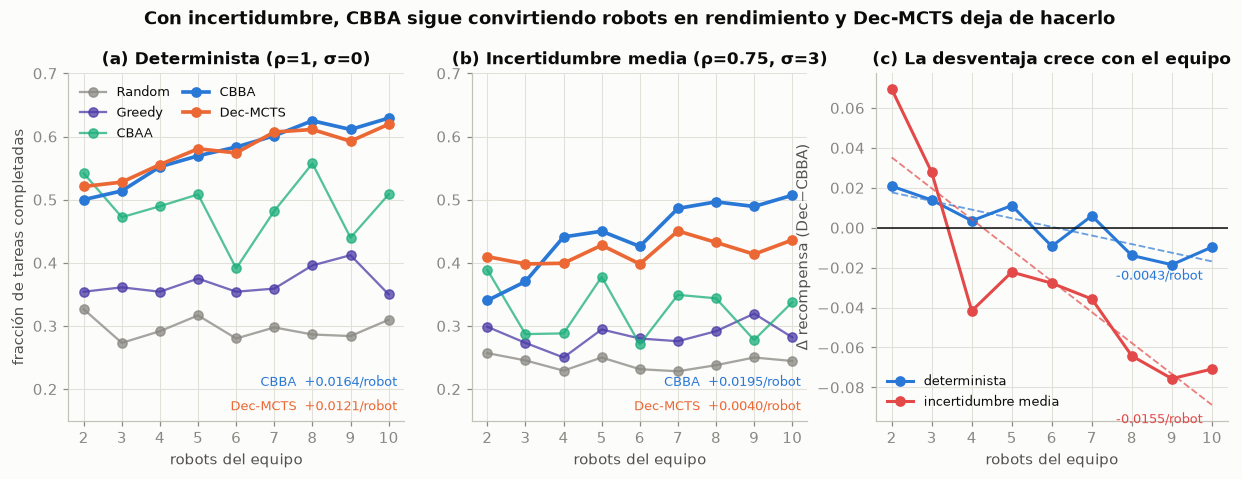

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.1), gridspec_kw={'width_ratios': [1, 1, 1.05]})

for ax, reg, tit in zip(axes[:2], ('det', 'est'),
                        ('(a) Determinista (ρ=1, σ=0)', '(b) Incertidumbre media (ρ=0.75, σ=3)')):
    s = A[A.regimen == reg]
    for sol in SOLVERS:
        y = s.groupby('robots')[sol].mean()
        ax.plot(y.index, y.values, marker='o', color=COLOR[sol], label=NOMBRE[sol],
                lw=2.4 if sol in (DEC, REF) else 1.5,
                zorder=3 if sol in (DEC, REF) else 2, alpha=1 if sol in (DEC, REF) else .75)
    for k, sol in enumerate((REF, DEC)):                 # pendientes, en una esquina libre
        b, _ = pendiente(s.robots, s[sol])
        ax.text(0.98, 0.10 - 0.07 * k, f'{NOMBRE[sol]}  {b:+.4f}/robot', transform=ax.transAxes,
                ha='right', fontsize=8.5, color=COLOR[sol])
    ax.set_xlabel('robots del equipo'); ax.set_ylim(0.15, 0.70); ax.set_title(tit)
    ax.set_xticks(range(2, 11))
axes[0].set_ylabel('fracción de tareas completadas')
axes[0].legend(loc='upper left', fontsize=8.5, ncol=2, columnspacing=1)

# (c) la Δ frente al tamaño del equipo
ax = axes[2]
for reg, c, lab in (('det', POS, 'determinista'), ('est', NEG, 'incertidumbre media')):
    s = A[A.regimen == reg]
    y = s.groupby('robots').delta.mean()
    ax.plot(y.index, y.values, marker='o', color=c, label=lab, lw=2)
    b, a = np.polyfit(s.robots, s.delta, 1)
    xs = np.array([2, 10]); ax.plot(xs, a + b * xs, color=c, ls='--', lw=1.2, alpha=.7)
    ax.annotate(f'{b:+.4f}/robot', (10, a + b * 10), xytext=(-6, -12),
                textcoords='offset points', ha='right', fontsize=8.5, color=c)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(range(2, 11)); ax.set_xlabel('robots del equipo')
ax.set_ylabel('Δ recompensa (Dec−CBBA)')
ax.set_title('(c) La desventaja crece con el equipo'); ax.legend(fontsize=8.5, loc='lower left')

fig.suptitle('Con incertidumbre, CBBA sigue convirtiendo robots en rendimiento y Dec-MCTS deja de hacerlo',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_A_escalado'); plt.show()

**Lectura.** Este es el bloque que mejor formula la tesis del trabajo.

**En determinista los dos escalan**: CBBA **+0.0164 por robot** (t = 6.6) y Dec-MCTS **+0.0121**
(t = 7.7). Que la pendiente de Dec-MCTS sea positiva y muy significativa es un resultado positivo
que conviene no enterrar: su coordinación **funciona**, y lo hace en un escenario donde añadir
robots no reduce el trabajo de cada uno. Frente a ellos, `CBAA` (−0.0020, t = −0.4) y `Greedy`
(+0.0034, t = 1.0) son **planos**: añadirles robots no les sirve de nada.

**Bajo incertidumbre el contraste se abre**: CBBA sube a **+0.0195 por robot** (t = 6.6) mientras
Dec-MCTS cae a **+0.0040 (t = 1.5)**, una pendiente **unas cinco veces menor y que no llega a
distinguirse de cero**. Y el dato más contundente del bloque es la pendiente de la propia Δ:
**−0.0155 por robot (t = −4.7)**. La desventaja no es un nivel, **crece linealmente con el tamaño
del equipo**: con 2 robots Dec-MCTS gana (+0.069) y con 10 pierde (−0.071).

Eso es exactamente lo que predice el mecanismo de **exceso de deconflicción**: Dec-MCTS cede las
tareas que cree cubiertas por un vecino a partir del plan que ese vecino ha comunicado; bajo
incertidumbre ese plan deja de cumplirse en cuanto una tarea falla o se alarga, y **cuantos más
vecinos hay sobre los que condicionar, más tareas se ceden por error**. En determinista la
pendiente de la Δ es −0.0043 (t = −2.0), tres veces menor.

## 2.2 · Bloque B — forma de la ventana de ejecución

Tres formas alternativas de ventana $[t_j^s, t_j^l]$ contra la estrecha del control, con el mismo
equipo y la misma carga: `P` elimina la **espera** conservando el plazo, `C` sustituye el plazo
por uno **escalonado** que no depende de $t_j^s$, y `A` amplía la ventana. El bloque mide qué
parte de la ventaja o la desventaja de cada método viene de la **estructura temporal** del
problema y no de su capacidad de asignar.

⚠️ La ventana escalonada es, de hecho, **~5 unidades más apretada** que la de solo plazo (plazo
medio 24.67 frente a 29.67; la estrecha 29.97 y la ancha 49.87): el `+10` que las otras tres
heredan de la anchura nominal no aplica a la escalonada, cuyo plazo no depende de $t_0$. Es
deliberado y correcto, pero hay que declararlo al leer el resultado.

In [14]:
B    = W[W.bloque == 'B']
ctrl = A[(A.robots.isin([2, 5, 10])) & (A.instancia <= 4)]          # control pareado exacto
comb = pd.concat([ctrl.assign(ventana='E'), B])

print('Recompensa media y Δ pareada por forma de ventana (E = control del bloque A)')
display(comb.groupby(['regimen', 'ventana'], observed=True).apply(fila, include_groups=False)
            .reindex([(r, v) for r in ('det', 'est') for v in ('E', 'P', 'C', 'A')]).round(3))

# Efecto del cambio de ventana sobre la Δ, pareado escenario a escenario contra su control
llave = lambda d: list(zip(d.robots, d.regimen, d.instancia))
base  = pd.Series(ctrl.delta.values, index=llave(ctrl))
print('\nEfecto de cambiar la ventana sobre la Δ (pareado contra el mismo escenario con ventana E)')
ef = {}
for v in ('P', 'C', 'A'):
    for r in ('det', 'est'):
        s = B[(B.ventana == v) & (B.regimen == r)]
        dd = s.delta.values - base.loc[llave(s)].values
        ef[(VENTANA[v].replace('\n', ' '), r)] = {'efecto sobre la Δ': dd.mean(),
                                                  'EE': pd.Series(dd).sem(), 'n': len(dd)}
display(pd.DataFrame(ef).T.round(4))

Recompensa media y Δ pareada por forma de ventana (E = control del bloque A)


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ     EE      t  \
regimen ventana                                                                
det     E         0.318   0.360  0.519  0.566     0.574  0.007  0.009  0.783   
        P         0.348   0.501  0.559  0.560     0.598  0.038  0.014  2.700   
        C         0.347   0.442  0.457  0.455     0.533  0.078  0.010  7.654   
        A         0.346   0.556  0.525  0.703     0.669 -0.034  0.011 -3.022   
est     E         0.250   0.292  0.368  0.432     0.425 -0.008  0.024 -0.333   
        P         0.284   0.406  0.436  0.444     0.464  0.021  0.012  1.719   
        C         0.286   0.370  0.419  0.417     0.447  0.030  0.017  1.723   
        A         0.293   0.441  0.486  0.572     0.565 -0.007  0.016 -0.439   

                    n     G    E    P     mejor  
regimen ventana                                  
det     E        12.0   5.0  4.0  3.0  Dec-MCTS  
        P        12.0   8.0  3.0  1.0  Dec-MCTS  
        C        12.0  12.0  0.0  0.0  Dec-MCTS  
        A        12.0   0.0  6.0  6.0      CBBA  
est     E        12.0   4.0  2.0  6.0      CBBA  
        P        12.0   8.0  0.0  4.0  Dec-MCTS  
        C        12.0   8.0  0.0  4.0  Dec-MCTS  
        A        12.0   6.0  0.0  6.0      CBBA


Efecto de cambiar la ventana sobre la Δ (pareado contra el mismo escenario con ventana E)


efecto sobre la Δ      EE     n
P · solo plazo (sin espera) det             0.0306  0.0111  12.0
                            est             0.0287  0.0182  12.0
C · plazo escalonado        det             0.0708  0.0131  12.0
                            est             0.0380  0.0290  12.0
A · ancha                   det            -0.0412  0.0110  12.0
                            est             0.0009  0.0205  12.0

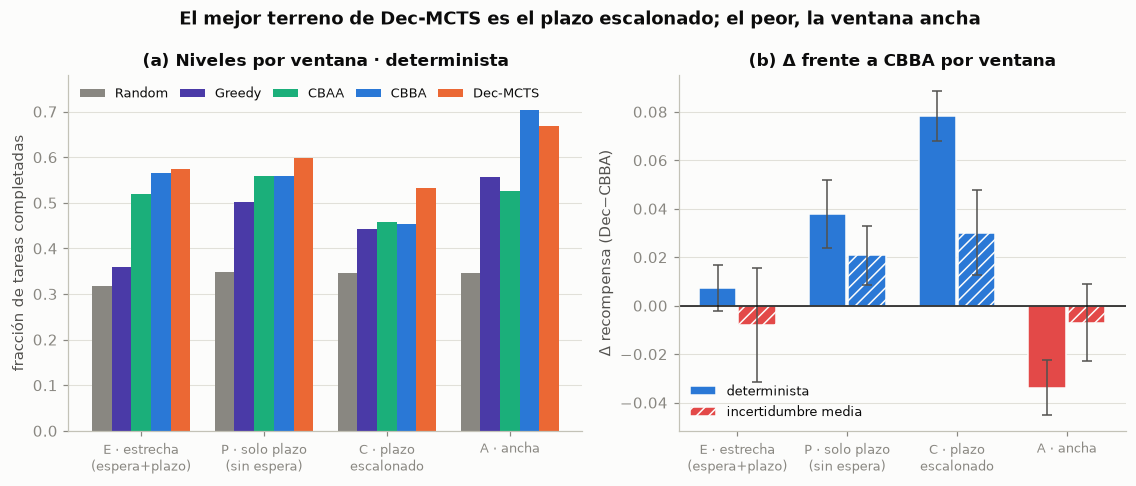

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})

ords = ['E', 'P', 'C', 'A']
# (a) niveles de los cinco solvers por ventana, régimen determinista
sub = comb[comb.regimen == 'det'].groupby('ventana', observed=True)[SOLVERS].mean().reindex(ords)
x, w = np.arange(4), 0.16
for k, s in enumerate(SOLVERS):
    ax1.bar(x + (k - 2) * w, sub[s].values, w, color=COLOR[s], label=NOMBRE[s])
ax1.set_xticks(x, [VENTANA[v] for v in ords], fontsize=8.5)
ax1.set_ylabel('fracción de tareas completadas'); ax1.set_ylim(0, 0.78)
ax1.set_title('(a) Niveles por ventana · determinista')
ax1.legend(ncol=5, fontsize=8.2, loc='upper left', columnspacing=.9)
ax1.grid(axis='x', visible=False)

# (b) Δ por ventana y régimen
for j, (reg, hatch, lab) in enumerate((('det', None, 'determinista'), ('est', '///', 'incertidumbre media'))):
    d = comb[comb.regimen == reg].groupby('ventana', observed=True).delta.agg(['mean', 'sem']).reindex(ords)
    ax2.bar(x + (j - 0.5) * 0.36, d['mean'], 0.34, yerr=d['sem'], hatch=hatch, label=lab,
            color=[POS if v > 0 else NEG for v in d['mean']], edgecolor=SURFACE,
            error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(x, [VENTANA[v] for v in ords], fontsize=8.5)
ax2.set_ylabel('Δ recompensa (Dec−CBBA)'); ax2.set_title('(b) Δ frente a CBBA por ventana')
ax2.legend(fontsize=8.5, loc='lower left'); ax2.grid(axis='x', visible=False)

fig.suptitle('El mejor terreno de Dec-MCTS es el plazo escalonado; el peor, la ventana ancha',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_B_ventana'); plt.show()

**Lectura.** El bloque produce el contraste más limpio de todo el catálogo, porque la ventana
cambia **qué tiene de difícil** el problema sin cambiar su tamaño.

- **Plazo escalonado (`C`) — el mejor terreno de Dec-MCTS**: Δ **+0.078 ± 0.010** en determinista,
  ganando **12 de 12 escenarios**, y +0.030 ± 0.017 con incertidumbre. Es la única ventana en la
  que Dec-MCTS es el mejor de los cinco por delante de CBBA (0.533 vs 0.455). Cuando los plazos
  son heterogéneos y no dependen del instante de apertura, **el orden de ejecución importa mucho
  más que el reparto**, y ahí una búsqueda que simula secuencias completas vale más que una puja
  que compromete un precio.
- **Sin espera (`P`)**: Δ +0.038 ± 0.014 en determinista. Quitar la espera —dejando el plazo—
  también le favorece: parte de su desventaja en el control viene de tener que *esperar* a que una
  tarea se abra, que es tiempo que su rollout descuenta y la puja no.
- **Ventana ancha (`A`) — el peor**: Δ **−0.034 ± 0.011**, **sin ganar uno solo de los 12
  escenarios**. Con ventanas
  holgadas el problema se vuelve casi un problema de reparto puro, sin apenas estructura temporal
  que explotar, y CBBA gana sin discusión (0.703 vs 0.669).

La conclusión del bloque es la que se repetirá en el resto: **Dec-MCTS aporta donde hay estructura
temporal que anticipar y no aporta donde el problema se reduce a repartir bien**.

## 2.3 · Bloque C — carga por robot

El factor de dificultad del catálogo. Con horizonte fijo, la carga por robot
$L = \sum_j q_j / R$ controla cuánto trabajo cabe realmente: $L = 3$ deja holgura y $L = 8$
satura. El bloque barre $L \in \{3, 4, 8\}$ sobre $R \in \{2, 5, 10\}$ y, junto con el control
$L = 6$ del bloque A, forma una **rejilla completa robots × carga** que separa los dos factores
que en los conjuntos de prueba iniciales del proyecto estaban confundidos.

⚠️ A diferencia de B y D, aquí el pareado **no es exacto**: cambiar $L$ cambia el número de tareas
$n$, así que los escenarios no son los mismos con otro parámetro sino escenarios distintos.

In [16]:
Cb   = W[W.bloque == 'C']
grid = pd.concat([Cb, ctrl])           # ctrl aporta la columna L=6 (bloque A, R ∈ {2,5,10})

print('Recompensa media por carga por robot')
display(grid.groupby(['regimen', 'carga'])[SOLVERS].mean()
            .rename(columns=NOMBRE).reindex([(r, l) for r in ('det', 'est') for l in (3, 4, 6, 8)])
            .round(3))
print('\nΔ pareada Dec-MCTS − CBBA en la rejilla robots × carga')
display(grid.pivot_table(index='robots', columns=['regimen', 'carga'], values='delta').round(3))

Recompensa media por carga por robot


Random  Greedy   CBAA   CBBA  Dec-MCTS
regimen carga                                        
det     3       0.531   0.589  0.608  0.800     0.930
        4       0.426   0.477  0.574  0.677     0.757
        6       0.318   0.360  0.519  0.566     0.574
        8       0.236   0.289  0.453  0.440     0.451
est     3       0.431   0.481  0.409  0.553     0.674
        4       0.342   0.362  0.388  0.515     0.588
        6       0.250   0.292  0.368  0.432     0.425
        8       0.188   0.224  0.325  0.376     0.324


Δ pareada Dec-MCTS − CBBA en la rejilla robots × carga


regimen    det                         est                     
carga        3      4      6      8      3      4      6      8
robots                                                         
2        0.208  0.167  0.021  0.078  0.167  0.135  0.069 -0.021
5        0.100  0.067  0.011 -0.006  0.156  0.104 -0.022 -0.056
10       0.081  0.006 -0.010 -0.036  0.042 -0.021 -0.071 -0.080

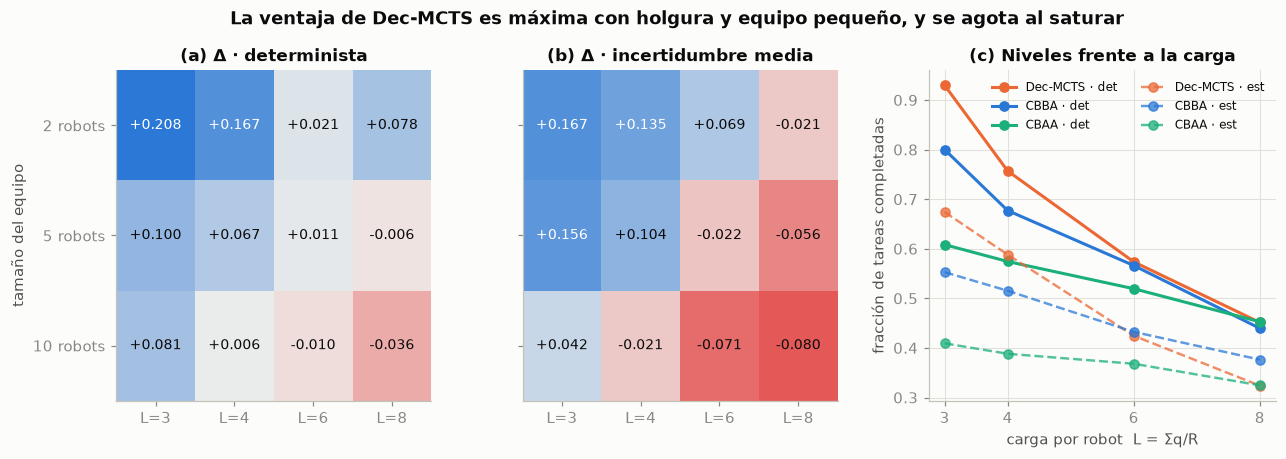

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.9), gridspec_kw={'width_ratios': [1, 1, 1.1],
                                                                 'wspace': 0.28})
Ls, Rs = [3, 4, 6, 8], [2, 5, 10]

for k, (ax, reg, tit) in enumerate(zip(axes[:2], ('det', 'est'),
                                       ('(a) Δ · determinista', '(b) Δ · incertidumbre media'))):
    m = grid[grid.regimen == reg].pivot_table(index='robots', columns='carga', values='delta')
    m = m.reindex(index=Rs, columns=Ls)
    ax.imshow(m.values, cmap=DIV, aspect='auto',
              norm=TwoSlopeNorm(vmin=-0.09, vcenter=0, vmax=0.21))
    for i in range(3):
        for j in range(4):
            ax.text(j, i, f'{m.values[i, j]:+.3f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(m.values[i, j]) > 0.13 else INK)
    ax.set_xticks(range(4), [f'L={l}' for l in Ls])
    ax.set_yticks(range(3), [f'{r} robots' for r in Rs] if k == 0 else [''] * 3)
    ax.set_title(tit); ax.grid(False)
axes[0].set_ylabel('tamaño del equipo')

# (c) niveles frente a la carga
ax = axes[2]
for reg, ls in (('det', '-'), ('est', '--')):
    for s in (DEC, REF, 'cbaa'):
        y = grid[grid.regimen == reg].groupby('carga')[s].mean().reindex(Ls)
        ax.plot(Ls, y.values, ls, marker='o', color=COLOR[s], lw=2 if ls == '-' else 1.6,
                label=f'{NOMBRE[s]} · {reg}', alpha=1 if ls == '-' else .75)
ax.set_xticks(Ls); ax.set_xlabel('carga por robot  L = Σq/R')
ax.set_ylabel('fracción de tareas completadas')
ax.set_title('(c) Niveles frente a la carga'); ax.legend(fontsize=7.8, ncol=2, loc='upper right')

fig.suptitle('La ventaja de Dec-MCTS es máxima con holgura y equipo pequeño, y se agota al saturar',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_C_carga'); plt.show()

**Lectura.** Es el **mejor bloque de Dec-MCTS** (Δ +0.061 ± 0.013) y el gradiente más limpio del
catálogo: la rejilla es **monótona en los dos ejes a la vez** —decreciente en la carga y
decreciente en el número de robots— con **una sola excepción** en las 24 celdas (2 robots, L=8,
determinista). La Δ va de **+0.208** (2 robots, L=3, determinista) a **−0.080** (10 robots, L=8,
incertidumbre).

La interpretación es directa y encaja con §2.1: **la anticipación vale cuando hay algo que
anticipar y alguien a quien no estorbar**. Con holgura ($L=3$) el problema no es *qué tareas
hacer* sino *en qué orden*, que es precisamente lo que una búsqueda sobre secuencias resuelve
mejor que una puja —Dec-MCTS llega a 0.930 frente a 0.800 de CBBA—. Con saturación ($L=8$) casi
toda la recompensa disponible se pierde por falta de tiempo, la calidad del orden deja de importar
y las dos políticas convergen (0.451 vs 0.440 en determinista) o se invierten bajo incertidumbre.

⚠️ **Este bloque es también el que sostiene el agregado global.** Es el que quitado voltea el
signo de la Δ del catálogo (§1.4), y su composición —dos de sus tres niveles, $L=3$ y $L=4$, están
en la zona favorable— es la principal razón de que el agregado salga positivo.

## 2.4 · Bloque D — coaliciones

El único bloque donde una tarea requiere **varios robots a la vez** ($q_j > 1$): `q2` exige dos
trabajadores en todas las tareas y `qm` mezcla requisitos de 1, 2 y 3 manteniendo $\bar q = 2$.
La carga por robot se mantiene en $L = 6$ reajustando el número de tareas ($m = Ln/\bar q$), de
modo que el trabajo total es el mismo que en el control y lo único que cambia es **que hay que
sincronizarse**.

In [18]:
D     = W[W.bloque == 'D']
ctrlD = A[A.robots.isin([3, 6, 10])]                       # control q1 a los mismos R
combD = pd.concat([ctrlD.assign(coalicion='q1'), D])

print('Recompensa media por tipo de coalición (q1 = control del bloque A)')
display(combD.groupby(['regimen', 'coalicion'], observed=True).apply(fila, include_groups=False)
             .reindex([(r, q) for r in ('det', 'est') for q in ('q1', 'q2', 'qm')]).round(3))
print('\nEl bloque completo, y quién lo gana:')
display(panel(D).round(3))
print('\nΔ por tamaño de equipo dentro de cada coalición:')
display(D.pivot_table(index='robots', columns=['regimen', 'coalicion'], values='delta').round(3))

Recompensa media por tipo de coalición (q1 = control del bloque A)


Random  Greedy   CBAA   CBBA  Dec-MCTS      Δ     EE  \
regimen coalicion                                                         
det     q1          0.288   0.355  0.457  0.575     0.574 -0.002  0.010   
        q2          0.145   0.312  0.472  0.441     0.388 -0.052  0.016   
        qm          0.246   0.307  0.519  0.503     0.527  0.023  0.011   
est     q1          0.240   0.278  0.298  0.434     0.411 -0.024  0.018   
        q2          0.109   0.267  0.347  0.306     0.310  0.004  0.012   
        qm          0.176   0.262  0.384  0.379     0.380  0.001  0.015   

                       t     n     G    E     P     mejor  
regimen coalicion                                          
det     q1        -0.175  12.0   4.0  3.0   5.0      CBBA  
        q2        -3.332  18.0   2.0  1.0  15.0      CBAA  
        qm         2.121  18.0  10.0  5.0   3.0  Dec-MCTS  
est     q1        -1.278  12.0   5.0  0.0   7.0      CBBA  
        q2         0.312  18.0   8.0  4.0   6.0      CBAA  
        qm         0.095  18.0   7.0  1.0  10.0      CBAA


El bloque completo, y quién lo gana:


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,mejor
catálogo completo,0.169033,0.286934,0.430555,0.407253,0.401234,-0.006018,0.007442,-0.80877,72.0,27.0,11.0,34.0,CBAA



Δ por tamaño de equipo dentro de cada coalición:


regimen      det           est       
coalicion     q2     qm     q2     qm
robots                               
3         -0.006  0.025  0.025  0.025
6         -0.059  0.052  0.022  0.000
10        -0.093 -0.007 -0.035 -0.020

findfont: Failed to find font weight semibold, now using 700.


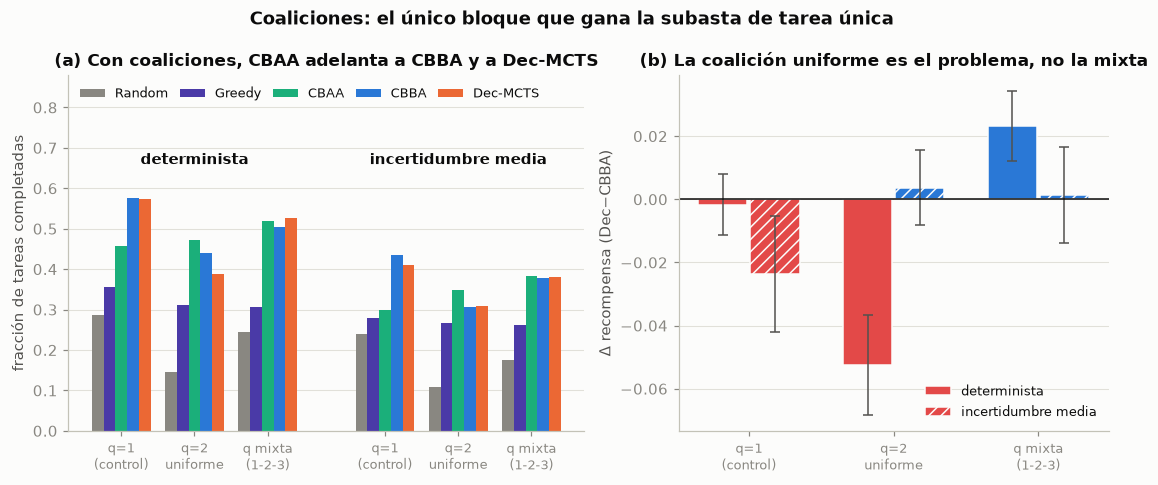

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.2), gridspec_kw={'width_ratios': [1.2, 1]})

qs  = ['q1', 'q2', 'qm']
eti = ['q=1\n(control)', 'q=2\nuniforme', 'q mixta\n(1-2-3)']
x, w = np.arange(3), 0.16
# (a) niveles por coalición, los dos regímenes uno al lado del otro
for j, reg in enumerate(('det', 'est')):
    sub = combD[combD.regimen == reg].groupby('coalicion', observed=True)[SOLVERS].mean().reindex(qs)
    for k, s in enumerate(SOLVERS):
        ax1.bar(x + j * 3.6 + (k - 2) * w, sub[s].values, w, color=COLOR[s],
                label=NOMBRE[s] if j == 0 else None)
ax1.set_xticks(list(x) + list(x + 3.6), eti + eti, fontsize=8.2)
ax1.text(1, 0.66, 'determinista', ha='center', fontsize=9.5, color=INK, fontweight='semibold')
ax1.text(4.6, 0.66, 'incertidumbre media', ha='center', fontsize=9.5, color=INK, fontweight='semibold')
ax1.set_ylim(0, 0.88); ax1.set_ylabel('fracción de tareas completadas')
ax1.set_title('(a) Con coaliciones, CBAA adelanta a CBBA y a Dec-MCTS')
ax1.legend(ncol=5, fontsize=8.2, loc='upper left', columnspacing=.9)
ax1.grid(axis='x', visible=False)

# (b) Δ por coalición y régimen
for j, (reg, hatch, lab) in enumerate((('det', None, 'determinista'), ('est', '///', 'incertidumbre media'))):
    d = combD[combD.regimen == reg].groupby('coalicion', observed=True).delta.agg(['mean', 'sem']).reindex(qs)
    ax2.bar(x + (j - .5) * .36, d['mean'], .34, yerr=d['sem'], hatch=hatch, label=lab,
            color=[POS if v > 0 else NEG for v in d['mean']], edgecolor=SURFACE,
            error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(x, eti, fontsize=8.5); ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) La coalición uniforme es el problema, no la mixta')
ax2.legend(fontsize=8.5, loc='lower right'); ax2.grid(axis='x', visible=False)

fig.suptitle('Coaliciones: el único bloque que gana la subasta de tarea única',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_D_coaliciones'); plt.show()

**Lectura.** Dos resultados, y los dos son contraintuitivos.

**1 · `CBAA` gana el bloque** (0.431) por delante de CBBA (0.407) y de Dec-MCTS (0.401), y lo gana
de forma clara: es el mejor en **45 de los 72 escenarios**. Es el único bloque del catálogo donde
la subasta de **tarea única** bate a la de **paquete**, lo que contradice la intuición habitual
—y el orden que CBAA ocupa en todos los demás cortes—. La explicación es coherente con lo que el
bloque introduce: cuando una tarea necesita $q_j$ robots simultáneos, comprometerse con un
**paquete** de tareas futuras es un pasivo, porque la coalición se forma o no se forma en el
momento y un robot con agenda cerrada no puede acudir. Pujar por una tarea cada vez deja libre
exactamente la flexibilidad que la sincronización exige.

**2 · La coalición uniforme y la mixta van en sentidos opuestos.** Dec-MCTS pierde con `q2`
(**−0.052 ± 0.016** en determinista) y **gana** con `qm` (**+0.023 ± 0.011**), aun teniendo las
dos la misma $\bar q = 2$ y la misma carga. El problema, por tanto, no es «coordinar coaliciones»
en general, sino la **decisión binaria** que toma su modelo de bloqueo: `blockingProb` decide si
los vecinos cubren o no una tarea preguntando si hay al menos $q_j$ vecinos que la lleven en su
paquete. Cuando **todas** las tareas exigen lo mismo, esa decisión se equivoca de forma sistemática
y correlacionada; cuando los requisitos son heterogéneos, los errores se descorrelacionan.

Y hay algo que el canal **no** puede transportar en ninguno de los dos casos: la noción de
**coalición parcial**. Un robot no puede comunicar «voy a esta tarea *si* alguien más viene», que
es justo la información que haría falta. Nótese que esto **ya falla en régimen determinista**,
donde el resto de los problemas de Dec-MCTS desaparecen: no es un efecto de la incertidumbre, es
una limitación del contenido del mensaje.

## 2.5 · Bloque E — gradiente de incertidumbre

El único bloque que barre la incertidumbre como factor: cuatro niveles
$\rho \in \{1.0, 0.9, 0.75, 0.5\}$ con $\sigma \in \{0, 1, 3, 5\}$ sobre la duración, es decir un
coeficiente de variación de 0 / 0.1 / 0.3 / 0.5, en tres tamaños de equipo. Es el **único bloque
sin mitad determinista**, y no por descuido: el régimen determinista *es* $\rho = 1.0$, o sea un
extremo del propio gradiente que el bloque recorre.

In [20]:
E = W[W.bloque == 'E']
print('Recompensa media a lo largo del gradiente de incertidumbre')
display(E.groupby('regimen', observed=True).apply(fila, include_groups=False).reindex(REGS).round(3))
print('\nΔ pareada por nivel de incertidumbre y tamaño de equipo')
display(E.pivot_table(index='regimen', columns='robots', values='delta').reindex(REGS).round(3))
g = E.groupby('regimen')[SOLVERS].mean().reindex(REGS)
print('\nCaída relativa de ρ=1 a ρ=0.5 (%):')
display(((g.loc['fue'] - g.loc['det']) / g.loc['det'] * 100).rename(NOMBRE).round(1).to_frame('%'))

Recompensa media a lo largo del gradiente de incertidumbre


,Random,Greedy,CBAA,CBBA,Dec-MCTS,Δ,EE,t,n,G,E,P,mejor
regimen,,,,,,,,,,,,,
det,0.302,0.365,0.524,0.563,0.570,0.007,0.007,0.940,18.0,6.0,5.0,7.0,Dec-MCTS
lev,0.261,0.340,0.471,0.520,0.510,-0.010,0.015,-0.645,18.0,4.0,3.0,11.0,CBBA
est,0.241,0.295,0.369,0.452,0.428,-0.024,0.013,-1.864,18.0,7.0,0.0,11.0,CBBA
fue,0.162,0.207,0.263,0.328,0.278,-0.050,0.017,-2.968,18.0,4.0,0.0,14.0,CBBA



Δ pareada por nivel de incertidumbre y tamaño de equipo


robots,2,5,10
regimen,,,
det,0.028,0.006,-0.013
lev,0.037,-0.006,-0.061
est,-0.000,0.004,-0.076
fue,0.005,-0.052,-0.102



Caída relativa de ρ=1 a ρ=0.5 (%):


,%
Random,-46.4
Greedy,-43.3
CBAA,-49.9
CBBA,-41.8
Dec-MCTS,-51.2


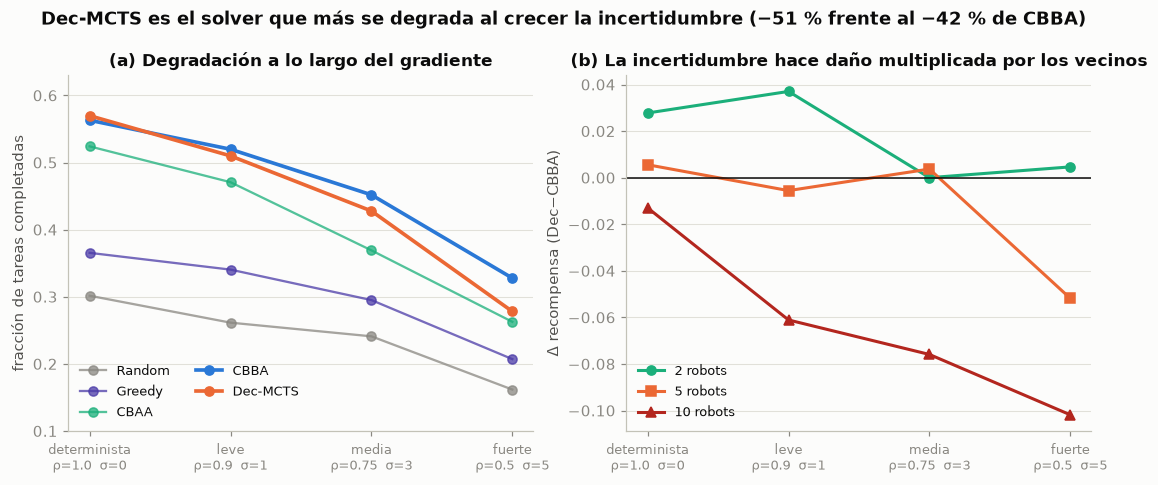

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) degradación de los cinco solvers
for s in SOLVERS:
    y = E.groupby('regimen')[s].mean().reindex(REGS)
    ax1.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
             lw=2.4 if s in (DEC, REF) else 1.5, zorder=3 if s in (DEC, REF) else 2,
             alpha=1 if s in (DEC, REF) else .75)
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('fracción de tareas completadas'); ax1.set_ylim(0.10, 0.63)
ax1.set_title('(a) Degradación a lo largo del gradiente')
ax1.legend(fontsize=8.5, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) Δ frente a la incertidumbre, por tamaño de equipo
for R, mk in zip((2, 5, 10), ('o', 's', '^')):
    y = E[E.robots == R].groupby('regimen').delta.mean().reindex(REGS)
    ax2.plot(range(4), y.values, marker=mk, label=f'{R} robots', lw=2,
             color={2: '#1baf7a', 5: '#eb6834', 10: '#b3261e'}[R])
ax2.axhline(0, color=INK, lw=1)
ax2.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax2.set_ylabel('Δ recompensa (Dec−CBBA)')
ax2.set_title('(b) La incertidumbre hace daño multiplicada por los vecinos')
ax2.legend(fontsize=8.5, loc='lower left'); ax2.grid(axis='x', visible=False)

fig.suptitle('Dec-MCTS es el solver que más se degrada al crecer la incertidumbre (−51 % frente al −42 % de CBBA)',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p2_E_incertidumbre'); plt.show()

**Lectura.** El gradiente ordena a los cinco solvers de forma monótona —todos caen— pero **no al
mismo ritmo**: de $\rho=1$ a $\rho=0.5$, Dec-MCTS pierde el **51.2 %** de su recompensa y CBBA el
**41.8 %**, el menor descenso de los cinco. El resultado es un cruce: Dec-MCTS es el mejor en
$\rho=1$ (0.570 vs 0.563) y el segundo, a distancia, en $\rho=0.5$ (0.278 vs 0.328).

La razón estructural de la robustez de CBBA merece enunciarse tal cual, porque es el núcleo del
argumento del trabajo: **una puja compromete un precio, no una trayectoria**. Cuando el plan de un
vecino se desvía, la puja sigue siendo válida —el precio se recalcula en la siguiente ronda—,
mientras que condicionar rollouts sobre planes muestreados deja de serlo.

El panel (b) aporta la confirmación más directa del mecanismo: **la incertidumbre no hace daño por
sí sola, hace daño multiplicada por el número de vecinos**. Con **2 robots** la Δ es positiva o
nula en los cuatro niveles de $\rho$ (+0.028, +0.037, −0.000, +0.005): la incertidumbre por sí
misma no perjudica a Dec-MCTS. Con **10 robots** la Δ se desploma de −0.013 a **−0.102** a lo largo
del mismo gradiente. Incertidumbre y tamaño de equipo **interactúan**, y ninguno de los dos
factores por separado explica el resultado.

---

# Parte 3 · Análisis adicional

La métrica objetivo —fracción de tareas completadas— resume el resultado pero esconde **cómo** se
llega a él. Esta parte examina cinco magnitudes que el simulador registra y que no entran en la
recompensa: cuántos robots se pierden por agotamiento de batería, cómo se descompone la
recompensa en intentar × acertar, cuánto se recorre, cuánto cuesta calcular y cuánto tiempo del
horizonte se aprovecha.

## 3.1 · Mortalidad de robots

Un robot muere cuando agota la batería y no alcanza una estación de recarga; queda fuera del
escenario para el resto de la ejecución. **Es un modo de fallo distinto de la mala asignación** y
hay que contabilizarlo aparte: parte de la desventaja de los baselines no es que asignen peor,
sino que **pierden flota**.

⚠️ Ocurre **también en régimen determinista**. Aunque $\rho = 1$, si al arrancar una tarea a un
robot no le queda batería suficiente, el simulador fuerza `success = false` y trunca la ejecución
(`simulator.cpp:469-473`); acto seguido `endTask` le cobra `averageFailDemand` **entera**
—10 unidades— porque `averageFailTime == 0` (`simulator.cpp:494-498`). Con una batería de 3.16
restante, el cargo de 10 deja al robot en −6.84 y lo mata.

In [22]:
MU = ancho('muertos')
tab = pd.DataFrame({'robots perdidos / escenario': MU[SOLVERS].mean(),
                    '% escenarios con bajas': 100 * (MU[SOLVERS] > 0).mean(),
                    'det': MU[MU.regimen == 'det'][SOLVERS].mean(),
                    'lev': MU[MU.regimen == 'lev'][SOLVERS].mean(),
                    'est': MU[MU.regimen == 'est'][SOLVERS].mean(),
                    'fue': MU[MU.regimen == 'fue'][SOLVERS].mean()}).rename(index=NOMBRE)
display(tab.round(3))
print('cbaa, cbba y dec-mcts: CERO robots perdidos en las 5 400 ejecuciones del catálogo.')

,robots perdidos / escenario,% escenarios con bajas,det,lev,est,fue
Random,1.984,85.278,1.854,1.704,2.115,2.259
Greedy,1.441,66.944,1.267,0.852,1.640,1.796
CBAA,0.000,0.000,0.000,0.000,0.000,0.000
CBBA,0.000,0.000,0.000,0.000,0.000,0.000
Dec-MCTS,0.000,0.000,0.000,0.000,0.000,0.000


cbaa, cbba y dec-mcts: CERO robots perdidos en las 5 400 ejecuciones del catálogo.


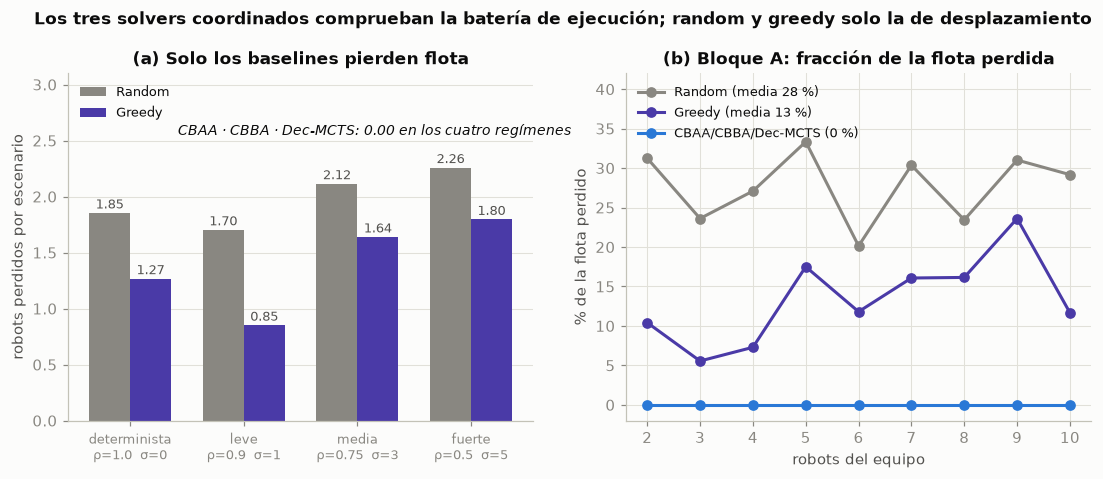

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) muertos por régimen
x, w = np.arange(4), 0.36
for j, s in enumerate(('random', 'greedy')):
    y = [MU[MU.regimen == r][s].mean() for r in REGS]
    ax1.bar(x + (j - .5) * w, y, w, color=COLOR[s], label=NOMBRE[s])
    for i, v in enumerate(y):
        ax1.text(i + (j - .5) * w, v + .04, f'{v:.2f}', ha='center', fontsize=8.5, color=INK2)
ax1.text(2.15, 2.55, 'CBAA · CBBA · Dec-MCTS: 0.00 en los cuatro regímenes',
         ha='center', fontsize=9, color=INK, style='italic')
ax1.set_xticks(x, [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylim(0, 3.1); ax1.set_ylabel('robots perdidos por escenario')
ax1.set_title('(a) Solo los baselines pierden flota'); ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(axis='x', visible=False)

# (b) fracción de la flota perdida frente al tamaño del equipo (bloque A, iso-dificultad)
a = MU[MU.bloque == 'A']
for s in ('random', 'greedy'):
    y = (a[s] / a.robots).groupby(a.robots).mean()
    ax2.plot(y.index, 100 * y.values, marker='o', color=COLOR[s],
             label=f'{NOMBRE[s]} (media {100 * (a[s] / a.robots).mean():.0f} %)')
ax2.plot(range(2, 11), [0] * 9, marker='o', color=COLOR[REF], label='CBAA/CBBA/Dec-MCTS (0 %)')
ax2.set_xticks(range(2, 11)); ax2.set_xlabel('robots del equipo')
ax2.set_ylabel('% de la flota perdido'); ax2.set_ylim(-2, 42)
ax2.set_title('(b) Bloque A: fracción de la flota perdida')
ax2.legend(fontsize=8.5, loc='upper left')

fig.suptitle('Los tres solvers coordinados comprueban la batería de ejecución; random y greedy solo la de desplazamiento',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_mortalidad'); plt.show()

**Lectura.** `Random` pierde **1.98 robots por escenario** (85.3 % de los escenarios tienen al
menos una baja) y `Greedy` **1.44** (66.9 %). `CBAA`, `CBBA` y `Dec-MCTS` no pierden **ni un solo
robot en las 5 400 ejecuciones** del catálogo. Sobre el bloque A, que mantiene la dificultad
constante al crecer el equipo, la magnitud que se conserva es la **fracción de flota**: `Random`
pierde el **27.7 %** de sus robots con independencia del tamaño del equipo (correlación de la
fracción con $R$: r = 0.01, frente a r = 0.72 del recuento absoluto) y `Greedy` el **13.3 %** con
una leve tendencia creciente (r = 0.23). No es un efecto de escala, es una tasa de la política.

La diferencia no es de suerte sino de diseño: los tres solvers coordinados comprueban antes de
comprometerse que la batería alcanza para **ejecutar** la tarea, no solo para **llegar** hasta
ella. `Random` y `Greedy` solo verifican el desplazamiento, arrancan tareas que no pueden terminar
y el mecanismo descrito arriba les cobra la demanda completa del fracaso.

⚠️ **Consecuencia para la lectura de todo el cuaderno**: parte de la ventaja de los tres métodos
coordinados sobre `Random` y `Greedy` —que en el agregado va de 0.08 (CBAA frente a Greedy) a
0.23 (Dec-MCTS frente a Random)— **no es calidad de asignación, es supervivencia**. Al comparar contra los baselines hay que decirlo. La comparación
que sostiene la tesis del trabajo, `Dec-MCTS` frente a `CBBA`, no está afectada: ninguno de los
dos pierde robots en ningún escenario.

## 3.2 · Descomposición de la recompensa: intentar × acertar

La fracción de tareas completadas se factoriza exactamente en dos términos observables:

$$\text{recompensa} \;=\; \underbrace{\frac{\text{tareas intentadas}}{n}}_{\text{tasa de intento}}
\;\times\; \underbrace{\frac{\text{tareas completadas}}{\text{tareas intentadas}}}_{\text{tasa de éxito}}$$

La primera mide **cuánto trabajo llega a emprender el equipo** —cobertura— y la segunda **con qué
acierto elige** lo que emprende. Separarlas dice si un algoritmo pierde por elegir mal o por no
llegar a intentarlo.

In [24]:
WI, WE = ancho('intento'), ancho('exito')
comp = pd.concat({'tasa de intento': WI.groupby('regimen')[SOLVERS].mean().reindex(REGS),
                  'tasa de éxito':   WE.groupby('regimen')[SOLVERS].mean().reindex(REGS)},
                 axis=1).rename(columns=NOMBRE)
display(comp.round(3))

di, de = WI[DEC] - WI[REF], (WE[DEC] - WE[REF]).fillna(0)
print(f'Correlación de la Δ de recompensa con…  Δ tasa de intento r = {np.corrcoef(W.delta, di)[0,1]:.3f}'
      f'   ·   Δ tasa de éxito r = {np.corrcoef(W.delta, de)[0,1]:.3f}')
print('\nTareas distintas que el equipo llega a intentar (media por escenario):')
display(esc.pivot_table(index='regimen', columns='solver', values='intentadas')
           .reindex(REGS)[SOLVERS].rename(columns=NOMBRE).round(2))

tasa de intento                               tasa de éxito         \
                 Random Greedy   CBAA   CBBA Dec-MCTS        Random Greedy   
regimen                                                                      
det               0.363  0.439  0.512  0.565    0.585         0.874  0.928   
lev               0.348  0.403  0.526  0.582    0.561         0.766  0.854   
est               0.393  0.483  0.516  0.615    0.593         0.643  0.690   
fue               0.399  0.471  0.540  0.679    0.588         0.417  0.451   

                                
          CBAA   CBBA Dec-MCTS  
regimen                         
det      1.000  1.000    1.000  
lev      0.897  0.896    0.910  
est      0.737  0.719    0.754  
fue      0.494  0.481    0.478

Correlación de la Δ de recompensa con…  Δ tasa de intento r = 0.768   ·   Δ tasa de éxito r = 0.417

Tareas distintas que el equipo llega a intentar (media por escenario):


solver,Random,Greedy,CBAA,CBBA,Dec-MCTS
regimen,,,,,
det,11.01,13.33,14.91,17.51,17.64
lev,11.89,13.57,17.35,20.94,19.57
est,11.90,14.71,14.64,19.26,17.75
fue,13.63,15.98,16.89,25.02,20.09


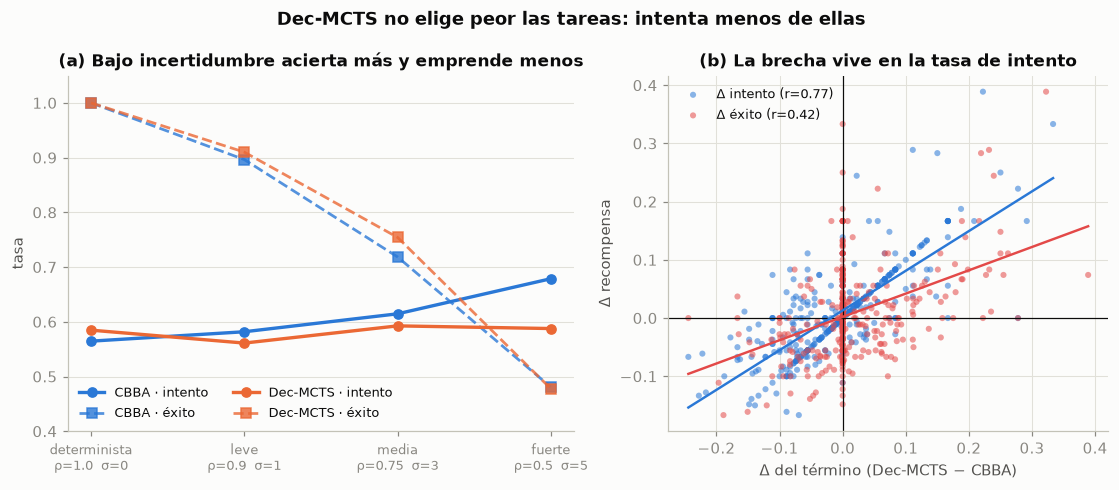

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})

# (a) intento y éxito de Dec-MCTS y CBBA a lo largo del gradiente
for s in (REF, DEC):
    ax1.plot(range(4), WI.groupby('regimen')[s].mean().reindex(REGS).values, marker='o',
             color=COLOR[s], lw=2.2, label=f'{NOMBRE[s]} · intento')
    ax1.plot(range(4), WE.groupby('regimen')[s].mean().reindex(REGS).values, marker='s', ls='--',
             color=COLOR[s], lw=1.8, alpha=.8, label=f'{NOMBRE[s]} · éxito')
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('tasa'); ax1.set_ylim(0.40, 1.05)
ax1.set_title('(a) Bajo incertidumbre acierta más y emprende menos')
ax1.legend(fontsize=8.2, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) qué término explica la Δ de recompensa
ax2.axhline(0, color=INK, lw=.8); ax2.axvline(0, color=INK, lw=.8)
ax2.scatter(di, W.delta, s=16, alpha=.55, color=POS, edgecolor='none', label=f'Δ intento (r={np.corrcoef(W.delta, di)[0,1]:.2f})')
ax2.scatter(de, W.delta, s=16, alpha=.55, color=NEG, edgecolor='none', label=f'Δ éxito (r={np.corrcoef(W.delta, de)[0,1]:.2f})')
for v, c in ((di, POS), (de, NEG)):
    b, a = np.polyfit(v, W.delta, 1); xs = np.linspace(v.min(), v.max(), 2)
    ax2.plot(xs, a + b * xs, color=c, lw=1.6)
ax2.set_xlabel('Δ del término (Dec-MCTS − CBBA)'); ax2.set_ylabel('Δ recompensa')
ax2.set_title('(b) La brecha vive en la tasa de intento'); ax2.legend(fontsize=8.5, loc='upper left')

fig.suptitle('Dec-MCTS no elige peor las tareas: intenta menos de ellas',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_mecanismo'); plt.show()

**Lectura.** El diagnóstico es inequívoco y va en contra de la explicación más obvia.

**La tasa de éxito de Dec-MCTS es superior a la de CBBA bajo incertidumbre**: 0.754 frente a
0.719 con $\rho=0.75$, y 0.910 frente a 0.896 con $\rho=0.9$. Dec-MCTS **no elige peor**; de las
tareas que emprende, termina una fracción mayor. El motivo es la batería: CBBA comprueba la
demanda con su valor **esperado** (`solver_CBBA.hpp:106`), de modo que con duraciones dispersas
empieza tareas que no puede acabar, mientras que Dec-MCTS muestrea duraciones en sus rollouts y
deja margen.

**Toda la brecha vive en la tasa de intento.** Con $\rho=0.75$ Dec-MCTS emprende 17.75 tareas
distintas por escenario frente a las 19.26 de CBBA (0.593 vs 0.615 de tasa); con $\rho=0.5$ la
distancia se dobla (0.588 vs 0.679). La correlación de la Δ de recompensa con la Δ de tasa de
intento es **r = 0.77**, frente a **r = 0.42** con la Δ de tasa de éxito.

Nótese la inversión respecto al régimen determinista, donde Dec-MCTS **emprende más** que CBBA
(0.585 vs 0.565) con idéntico éxito (1.000 los dos). El déficit de intento **solo aparece bajo
incertidumbre**, que es exactamente la firma del exceso de deconflicción descrito en §2.1: se
ceden tareas que se creen cubiertas por planes ajenos que ya no se van a cumplir, y acaban sin que
las haga nadie.

## 3.3 · Distancia recorrida

In [26]:
DR, DT, CO = ancho('dist_robot'), ancho('distancia'), ancho('completadas')
efic = (DT[SOLVERS] / CO[SOLVERS].replace(0, np.nan))
dist = pd.DataFrame({'distancia por robot': DR[SOLVERS].mean(),
                     'distancia total': DT[SOLVERS].mean(),
                     'distancia por tarea completada': efic.mean(),
                     'det': DR[DR.regimen == 'det'][SOLVERS].mean(),
                     'est': DR[DR.regimen == 'est'][SOLVERS].mean(),
                     'fue': DR[DR.regimen == 'fue'][SOLVERS].mean()}).rename(index=NOMBRE)
display(dist.round(2))
print(f'Sobrecoste de desplazamiento de Dec-MCTS frente a CBBA: '
      f'{100 * (DR[DEC].mean() / DR[REF].mean() - 1):+.1f} % por robot, '
      f'{100 * (efic[DEC].mean() / efic[REF].mean() - 1):+.1f} % por tarea completada.')

,distancia por robot,distancia total,distancia por tarea completada,det,est,fue
Random,15.94,93.42,16.44,15.50,16.41,16.45
Greedy,10.75,58.52,7.46,10.58,10.94,10.86
CBAA,13.93,76.25,7.13,13.90,13.81,14.59
CBBA,15.50,91.78,7.44,14.60,16.04,18.75
Dec-MCTS,19.42,114.11,8.86,17.81,20.53,22.91


Sobrecoste de desplazamiento de Dec-MCTS frente a CBBA: +25.3 % por robot, +19.1 % por tarea completada.


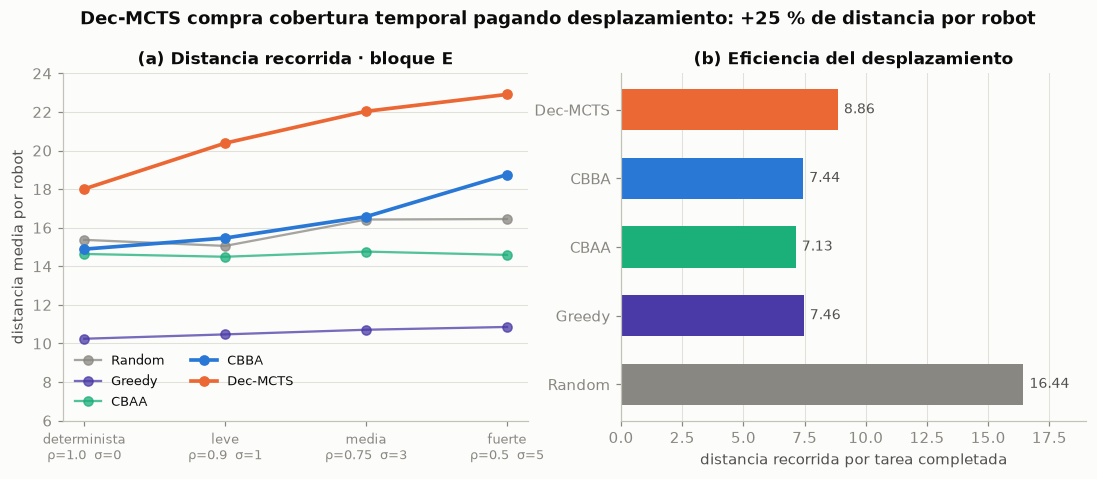

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) distancia por robot a lo largo del gradiente (bloque E, el único con los cuatro niveles)
E_idx = DR.bloque == 'E'
for s in SOLVERS:
    y = DR[E_idx].groupby('regimen')[s].mean().reindex(REGS)
    ax1.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
             lw=2.4 if s in (DEC, REF) else 1.5, alpha=1 if s in (DEC, REF) else .75)
ax1.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
ax1.set_ylabel('distancia media por robot'); ax1.set_ylim(6, 24)
ax1.set_title('(a) Distancia recorrida · bloque E')
ax1.legend(fontsize=8.5, ncol=2, loc='lower left'); ax1.grid(axis='x', visible=False)

# (b) distancia pagada por cada tarea completada
m = efic.mean().reindex(SOLVERS)
ax2.barh(range(5), m.values, .6, color=[COLOR[s] for s in m.index])
ax2.set_yticks(range(5), [NOMBRE[s] for s in m.index])
for i, v in enumerate(m.values):
    ax2.text(v + .25, i, f'{v:.2f}', va='center', fontsize=9, color=INK2)
ax2.set_xlim(0, 19); ax2.set_xlabel('distancia recorrida por tarea completada')
ax2.set_title('(b) Eficiencia del desplazamiento'); ax2.grid(axis='y', visible=False)

fig.suptitle('Dec-MCTS compra cobertura temporal pagando desplazamiento: +25 % de distancia por robot',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_distancia'); plt.show()

**Lectura.** Dec-MCTS recorre **19.4 unidades por robot frente a las 15.5 de CBBA (+25 %)**, y la
brecha se ensancha con la incertidumbre (+28 % con $\rho=0.75$, +22 % con $\rho=0.5$). Medido por
unidad de resultado, paga **8.86 de distancia por cada tarea completada** frente a 7.44 de CBBA y
7.13 de CBAA —el más eficiente de los cinco en este criterio—.

Es una caracterización operativa útil: **Dec-MCTS compra cobertura temporal pagando
desplazamiento**. Sus rollouts valoran llegar a tiempo a una ventana que se abre lejos, aunque el
viaje sea largo; una puja, que compromete un precio, descuenta ese viaje en el precio y tiende a
quedarse cerca. Mientras navegar sea barato el sobrecoste es inocuo —y de hecho es parte de cómo
gana en los bloques B y C—, pero **deja de serlo en cuanto el desplazamiento es el recurso que
ata**: con batería escasa y navegación cara, medido durante el desarrollo, llega a perder 12 de 12
escenarios.

`Random` es el caso degenerado opuesto: recorre 15.9 por robot, tanto como CBBA, y necesita
**16.44 de distancia por tarea completada** —el doble que cualquier otro— porque buena parte de
ese recorrido termina en tareas fallidas o en robots que se quedan sin batería por el camino.

## 3.4 · Coste computacional

⚠️ **Los tiempos de esta sección no son comparables en valor absoluto con una ejecución aislada.**
La tanda se lanzó con **6 procesos en paralelo** sobre la misma máquina, de modo que
`computing_time` incorpora contención por CPU. Las comparaciones **entre solvers** y las
**tendencias** sí son válidas, porque todos sufrieron las mismas condiciones. El número de
iteraciones de MCTS es fijo, así que el coste no afecta a la calidad de las soluciones: una
implementación más rápida daría los mismos resultados.

In [28]:
CP = ancho('cpu')
cost = pd.DataFrame({'s / ejecución (media)': CP[SOLVERS].mean(),
                     'mediana': CP[SOLVERS].median(),
                     'máximo': CP[SOLVERS].max(),
                     'veces CBBA': CP[SOLVERS].mean() / CP[REF].mean()}).rename(index=NOMBRE)
display(cost.round(4))
print('\nCoste frente al tamaño del equipo (bloque A, s por ejecución):')
display(CP[CP.bloque == 'A'].groupby('robots')[SOLVERS].mean().rename(columns=NOMBRE).round(3))

,s / ejecución (media),mediana,máximo,veces CBBA
Random,0.0009,0.0007,0.0045,0.1111
Greedy,0.0011,0.0008,0.0092,0.1330
CBAA,0.0015,0.0011,0.0184,0.1818
CBBA,0.0082,0.0023,0.0794,1.0000
Dec-MCTS,15.3227,6.7945,88.2828,1863.5956



Coste frente al tamaño del equipo (bloque A, s por ejecución):


,Random,Greedy,CBAA,CBBA,Dec-MCTS
robots,,,,,
2,0.000,0.000,0.000,0.000,0.552
3,0.000,0.000,0.000,0.001,1.604
4,0.001,0.002,0.001,0.001,3.771
5,0.001,0.001,0.001,0.003,6.453
6,0.001,0.001,0.001,0.004,11.197
7,0.001,0.001,0.002,0.006,15.129
8,0.001,0.002,0.002,0.009,23.209
9,0.002,0.003,0.003,0.018,31.953
10,0.002,0.002,0.003,0.024,44.405


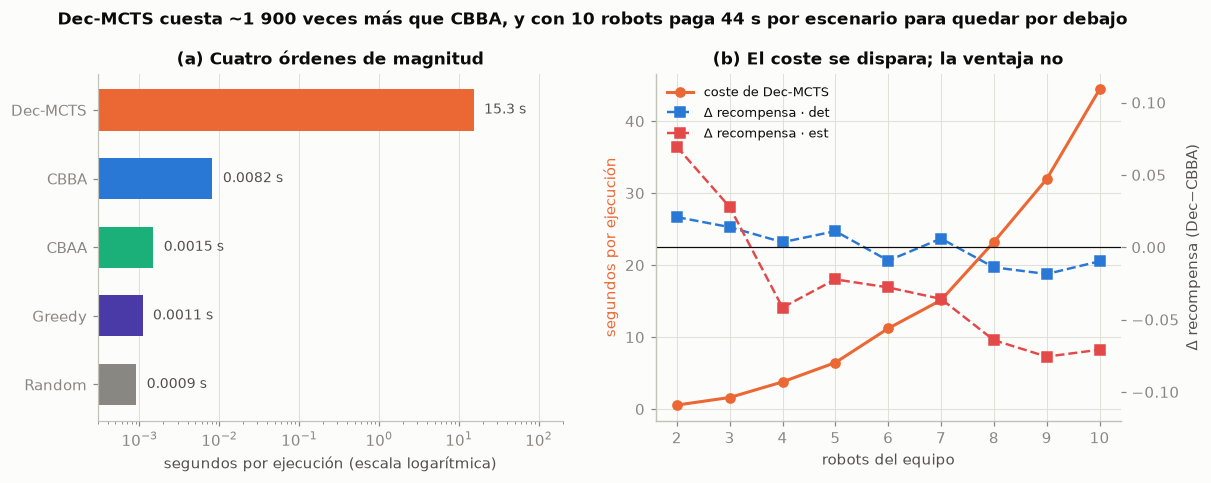

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# (a) coste por solver, escala logarítmica
m = CP[SOLVERS].mean().reindex(SOLVERS)
ax1.barh(range(5), m.values, .6, color=[COLOR[s] for s in m.index])
ax1.set_yticks(range(5), [NOMBRE[s] for s in m.index]); ax1.set_xscale('log')
for i, v in enumerate(m.values):
    ax1.text(v * 1.35, i, f'{v:.4f} s' if v < 1 else f'{v:.1f} s', va='center', fontsize=9, color=INK2)
ax1.set_xlim(3e-4, 2e2); ax1.set_xlabel('segundos por ejecución (escala logarítmica)')
ax1.set_title('(a) Cuatro órdenes de magnitud'); ax1.grid(axis='y', visible=False)

# (b) cómo escala el coste frente a la ventaja obtenida
a = CP[CP.bloque == 'A']
ax2.plot(a.groupby('robots')[DEC].mean().index, a.groupby('robots')[DEC].mean().values,
         marker='o', color=COLOR[DEC], label='coste de Dec-MCTS')
ax2.set_xlabel('robots del equipo'); ax2.set_ylabel('segundos por ejecución', color=COLOR[DEC])
ax2.set_xticks(range(2, 11)); ax2.set_title('(b) El coste se dispara; la ventaja no')
ax3 = ax2.twinx(); ax3.grid(False)
for reg, c in (('det', POS), ('est', NEG)):
    y = W[(W.bloque == 'A') & (W.regimen == reg)].groupby('robots').delta.mean()
    ax3.plot(y.index, y.values, marker='s', ls='--', lw=1.6, color=c, label=f'Δ recompensa · {reg}')
ax3.axhline(0, color=INK, lw=.8)
ax3.set_ylabel('Δ recompensa (Dec−CBBA)', color=INK2); ax3.set_ylim(-0.12, 0.12)
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8.5, loc='upper left')

fig.suptitle('Dec-MCTS cuesta ~1 900 veces más que CBBA, y con 10 robots paga 44 s por escenario para quedar por debajo',
             fontsize=11, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_coste'); plt.show()

**Lectura.** El coste separa a los cinco algoritmos en tres regímenes: `Random`, `Greedy` y `CBAA`
por debajo del milisegundo y medio; `CBBA` en **8.2 ms**; `Dec-MCTS` en **15.3 s de media**
(mediana 6.8 s, máximo 88 s). Son **tres órdenes de magnitud** sobre CBBA —unas 1 900 veces— para
una diferencia de recompensa que en el agregado es +0.009.

El panel (b) es el resumen honesto del compromiso: el coste de Dec-MCTS crece de 0.55 s con
2 robots a **44.4 s con 10** —el árbol ramifica sobre un espacio conjunto que crece con la flota—
mientras que su ventaja recorre el camino contrario y **se vuelve negativa exactamente donde el
coste se dispara**. Para el operador la lectura es que la anticipación por búsqueda solo renta en
equipos pequeños o medianos y con planes predecibles; en el resto del espacio se paga tiempo de
cómputo por un resultado peor.

⚠️ Lo que estos números **no** dicen: que Dec-MCTS sea irremediablemente lento. Su presupuesto de
iteraciones es un hiperparámetro fijo y el coste es lineal en él; multiplicarlo por 40 durante el
desarrollo no mejoró el rendimiento, así que el problema tampoco se arregla gastando más.

## 3.5 · Ocupación del horizonte

Dos magnitudes temporales que el registro proporciona: el **makespan** del robot más tardío —cuándo
se detiene la última actividad del equipo— y el **instante medio de retirada**, el momento en que
cada robot deja de operar, ya sea porque termina su plan, porque se queda sin tareas alcanzables o
porque agota la batería. Con horizonte fijo $T = 40$ y ventanas que se extienden más allá, ambas
miden **cuánto del tiempo disponible aprovecha cada política**.

In [30]:
MK, RT = ancho('makespan'), ancho('retiro')
temp = pd.concat({'makespan máximo': MK.groupby('regimen')[SOLVERS].mean().reindex(REGS),
                  'instante medio de retirada': RT.groupby('regimen')[SOLVERS].mean().reindex(REGS)},
                 axis=1).rename(columns=NOMBRE)
display(temp.round(2))

makespan máximo                                \
                 Random Greedy   CBAA   CBBA Dec-MCTS   
regimen                                                 
det               53.69  54.46  58.96  57.34    60.46   
lev               55.19  56.38  58.90  58.07    59.59   
est               53.31  54.46  58.25  56.48    58.60   
fue               54.06  55.86  57.46  56.53    56.65   

        instante medio de retirada                                
                            Random Greedy   CBAA   CBBA Dec-MCTS  
regimen                                                           
det                          50.90  50.78  44.40  49.06    54.94  
lev                          52.15  52.20  43.57  49.12    54.53  
est                          50.92  51.03  37.40  46.21    52.41  
fue                          50.12  51.06  31.89  44.41    49.65

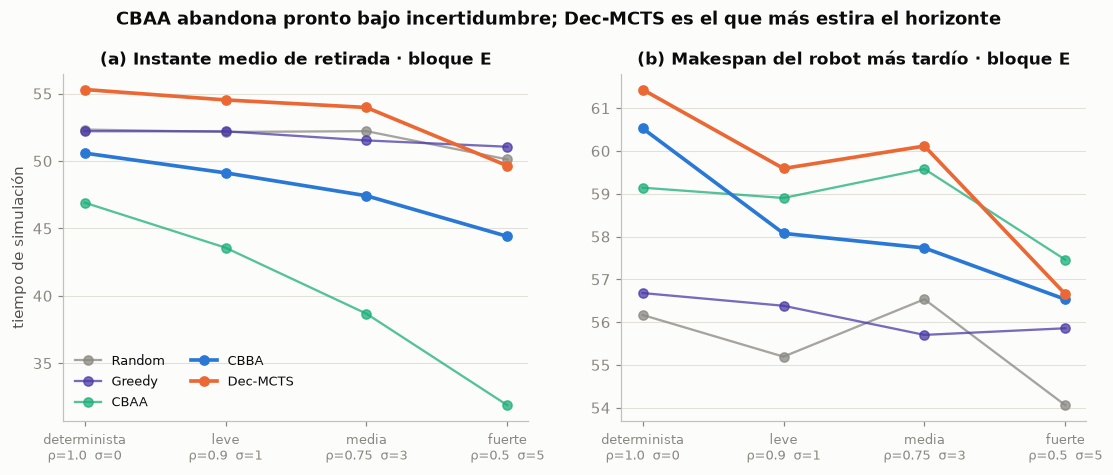

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

for ax, T, tit in ((ax1, RT, '(a) Instante medio de retirada'),
                   (ax2, MK, '(b) Makespan del robot más tardío')):
    for s in SOLVERS:
        y = T[T.bloque == 'E'].groupby('regimen')[s].mean().reindex(REGS)
        ax.plot(range(4), y.values, marker='o', color=COLOR[s], label=NOMBRE[s],
                lw=2.4 if s in (DEC, REF) else 1.5, alpha=1 if s in (DEC, REF) else .75)
    ax.set_xticks(range(4), [REGIMEN[r] for r in REGS], fontsize=8.5)
    ax.set_title(tit + ' · bloque E'); ax.grid(axis='x', visible=False)
ax1.set_ylabel('tiempo de simulación'); ax1.legend(fontsize=8.5, ncol=2, loc='lower left')

fig.suptitle('CBAA abandona pronto bajo incertidumbre; Dec-MCTS es el que más estira el horizonte',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, 'p3_tiempos'); plt.show()

**Lectura.** El instante medio de retirada separa a los solvers por su capacidad de **seguir
encontrando trabajo**. `Dec-MCTS` es el que más estira el horizonte (54.9 en determinista y 52.4
con $\rho=0.75$ sobre el conjunto del catálogo) y `CBAA` el que antes lo abandona. A lo largo del
gradiente del bloque E el contraste es nítido: Dec-MCTS apenas cede (**55.3 → 49.7**) mientras que
CBAA se desploma (**46.9 → 31.9**). CBAA no pierde robots por batería (§3.1), así que su retirada temprana
significa otra cosa: sus robots **se quedan sin tareas que pujar** que sigan siendo alcanzables
dentro de plazo, y paran. Eso explica por qué su tasa de intento es baja bajo incertidumbre pese a
no tener bajas, y es coherente con que su pendiente frente al tamaño del equipo sea plana (§2.1):
añadirle robots no le da más cobertura, solo más agentes ociosos.

El makespan, en cambio, apenas discrimina (entre 53 y 61 en todos los cortes): todos los solvers mantienen
*algún* robot activo hasta bien entrado el horizonte, de modo que la diferencia no está en cuándo
se para el último, sino en **cuántos siguen trabajando** hasta entonces.

---

# Síntesis

**Lo que el catálogo permite afirmar.**

1. **Los tres primeros escalones del ranking son sólidos y no dependen del corte.** Coordinarse
   vale: `Random` 0.271 → `Greedy` 0.354 → `CBAA` 0.437 → `CBBA` 0.494. Dec-MCTS gana a `Random`
   en 358 de 360 escenarios y a `Greedy` en 333.
2. **El último escalón es un empate, y su signo depende de la composición del catálogo.** Δ global
   +0.0086 ± 0.0040, con 158 victorias frente a 160 derrotas y mediana exactamente cero; quitar el
   bloque C invierte el resultado. **Nunca liderar con el agregado.**
3. **En determinista Dec-MCTS gana** (+0.020 ± 0.006) y **bajo incertidumbre fuerte pierde con
   claridad** (−0.050 ± 0.017). La anticipación paga mientras los planes son predecibles.
4. **El resultado más nítido es el de escalado**: bajo incertidumbre CBBA convierte cada robot
   adicional en +0.0195 de recompensa (t = 6.6) y Dec-MCTS en +0.0040 (t = 1.5), una pendiente
   cinco veces menor que no se distingue de cero; **la Δ cae −0.0155 por robot (t = −4.7)**. La
   desventaja crece linealmente con el tamaño del equipo.
5. **El mecanismo está identificado**: la brecha no está en elegir peor —Dec-MCTS tiene **mayor**
   tasa de éxito bajo incertidumbre— sino en **intentar menos** (r = 0.77 con la Δ de recompensa,
   frente a r = 0.42 de la tasa de éxito). Es la firma del exceso de deconflicción: se ceden tareas
   que se creen cubiertas por planes ajenos que la incertidumbre ya ha invalidado.
6. **Hay terreno propio de Dec-MCTS, y es reconocible**: plazos escalonados (+0.078, 12 de 12
   escenarios), ausencia de espera (+0.038) y carga holgada (+0.208 con 2 robots y L=3). Todo él
   comparte una propiedad: **estructura temporal que anticipar y pocos vecinos a los que ceder
   trabajo por error**.
7. **Dos hallazgos que no estaban en la hipótesis de partida**: `CBAA` **gana el bloque de
   coaliciones** (0.431 frente a 0.407 de CBBA) —la subasta de tarea única bate a la de paquete
   justo donde hay que sincronizarse—, y la coalición **mixta** se comporta al revés que la
   uniforme (+0.023 frente a −0.052 en determinista), lo que señala a la decisión **binaria** de
   `blockingProb` y no a las coaliciones en general.

**Lo que hay que declarar al presentar estos resultados.**

- La **composición del catálogo** condiciona el agregado, y el v3 tiene dos de los tres niveles de
  B y de C en terreno favorable a Dec-MCTS (§1.4).
- La **mortalidad de robots** de `Random` y `Greedy` —hasta 2.3 bajas por escenario, y también en
  régimen determinista— es parte de su desventaja y **no es calidad de asignación** (§3.1).
- Los **tiempos de cómputo** proceden de una tanda con 6 procesos en paralelo: comparables entre
  solvers, no en valor absoluto (§3.4).
- La **ventana escalonada** es ~5 unidades más apretada que la de solo plazo, lo que hay que
  mencionar al destacarla como el mejor terreno de Dec-MCTS (§2.2).
- No hay **semilla configurable** (`std::random_device`): las 3 réplicas promedian, pero la tanda
  no es reproducible bit a bit.